## Imports

In [1]:
# Standard Libraries
import os
import csv
import math
import copy
import pickle
from functools import reduce
import datetime as dt

# Data Handling & Analysis
import numpy as np
import pandas as pd
import scipy.stats
import hydroeval as he
from sklearn.metrics import mean_squared_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
from adjustText import adjust_text
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, MultipleLocator

# SWMM API
from swmm_api import __version__, read_rpt_file, read_inp_file, read_out_file, swmm5_run
from swmm_api.output_file import OBJECTS, VARIABLES
from swmm_api.input_file import SwmmInput, section_labels as sections
from swmm_api.input_file.sections import Outfall
from swmm_api.input_file.section_labels import TIMESERIES
from swmm_api.input_file.macros.plotting_map import plot_map, add_node_labels
from swmm_api.input_file.macros.plotting_longitudinal import plot_longitudinal


### Functions

In [2]:
def load_runoff_obs_to_df(OBS_RUNOFF_DATA_PATH):
    """ Takes OBSERVATION FILE with runoff data and makes pd Dataframe
    :param output_path: str, path name that have the runoff data
    :return: df_obs_runoff
    """
    df_obs_runoff = pd.read_csv (OBS_RUNOFF_DATA_PATH + ".csv")
    df_obs_runoff.dropna(inplace = True) ; df_obs_runoff.rename(columns={'discharge_cms': 'OBS runoff [CMS]'} , inplace=True, errors='raise')
    df_obs_runoff["date_and_time"] =  pd.to_datetime(df_obs_runoff["date_and_time"], format='%d/%m/%Y %H:%M:%S')
    df_obs_runoff = df_obs_runoff.set_index('date_and_time')
    df_obs_runoff.drop(['Unnamed: 0'], axis=1, inplace=True)


    return df_obs_runoff
    
# df_runoff.to_pickle('df_runoff.pkl')

In [3]:
def data_5min_interpolate(df_to_interpolate):
    """ Takes df column and makes 5 min interpolation
    :param df_to_interpolate: pd, df with index datetime64 type
    :return: df_interpol
    """
    df_interpol = df_to_interpolate.resample('5min').mean()
#     df_interpol= df_interpol.interpolate(method='polynomial', order=3)
    df_interpol= df_interpol.interpolate(method='linear')
    return df_interpol

In [4]:
def load_sim_to_df(sim_output_path):
    """ Takes SWMM FILE with runoff data and makes pd Dataframe
    sim_output_path: str, file name that have the swmm outflow data
    return: sim_df
    """
    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['outflow', 'rainfall']]
    sim_df.rename(columns={'outflow':'SWMM outflow [CMS]', 'rainfall':'rainfall [mm/h]'}, inplace=True, errors='raise')
    sim_df.index = pd.to_datetime(sim_df.index)
    return sim_df

In [5]:
def update_imperviousness_with_factor(subcatchment_dict, factor):
    """
    Update the imperviousness values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which imperviousness values need to be powered.

    Returns:
        dict: The updated dictionary with imperviousness values powered by the factor.
    """
#     impervious_initial_values = [21, 43, 47, 47, 51, 47, 51, 47, 43, 22, 37, 18, 24, 37, 47, 35, 45, 71, 19]
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
#         initial_imperviousness = impervious_initial_values[index]
#         subcatchment.imperviousness = initial_imperviousness
        powered_imperviousness = subcatchment.imperviousness * factor
        # Update the imperviousness value for the current subcatchment with the powered imperviousness value
        subcatchment.imperviousness = powered_imperviousness


    # Return the updated dictionary
    return subcatchment_dict

def update_storage_with_factor(subareas_dict, factor):
    """
    Update the storage values of SubArea objects in a dictionary by a factor.

    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        factor (float): The factor by which storage values need to be powered.

    Returns:
        dict: The updated dictionary with storage values powered by the factor.
    """
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        # Access the impervious and pervious storage values for the current subarea
        imp_storage = subarea.storage_imperv
        perv_storage = subarea.storage_perv
        # Multiply the impervious and pervious storage values by the factor
        powered_imp_storage = imp_storage * factor
        powered_perv_storage = perv_storage * factor
        # Update the storage values for the current subarea with the powered values
        subarea.storage_imperv = powered_imp_storage
        subarea.storage_perv = powered_perv_storage

    # Return the updated dictionary
    return subareas_dict


def update_n_with_factor(subareas_dict, factor):
    """
    Update the n_imperv and n_perv values of SubArea objects in a dictionary by a factor.

    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        factor (float): The factor by which n_imperv and n_perv values need to be multiplied.

    Returns:
        dict: The updated dictionary with n_imperv and n_perv values multiplied by the factor.
    """
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        # Access the impervious and pervious n values for the current subarea
        imp_n = subarea.n_imperv
        perv_n = subarea.n_perv
        # Multiply the impervious and pervious n values by the factor
        updated_imp_n = imp_n * factor
        updated_perv_n = perv_n * factor
        # Update the n values for the current subarea with the multiplied values
        subarea.n_imperv = updated_imp_n
        subarea.n_perv = updated_perv_n

    # Return the updated dictionary
    return subareas_dict


def update_width_with_factor(subcatchment_dict, factor, width_initial_values):
    """
    Update the width values of SubCatchment objects in a dictionary by a factor.

    Args:
        subcatchment_dict (dict): A dictionary containing SubCatchment objects as values with subcatchment names as keys.
        factor (float): The factor by which width values need to be powered.
        width_initial_values (numpy.ndarray): A NumPy array of initial width values corresponding to each subcatchment.

    Returns:
        dict: The updated dictionary with width values powered by the factor.
    """
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, subcatchment) in enumerate(subcatchment_dict.items()):
        width = width_initial_values[index]  # Get the initial width value for the current subcatchment
        powered_width = width * factor
        subcatchment.width = powered_width

    # Return the updated dictionary
    return subcatchment_dict


def update_curve_num_with_factor(infiltration_dict, factor, curve_no_initial_values):
    """
    Update the curve_no values of InfiltrationCurveNumber objects in a dictionary by a factor.

    Args:
        infiltration_dict (dict): A dictionary containing InfiltrationCurveNumber objects as values with subcatchment
                                  names as keys.
        factor (float): The factor by which curve_no values need to be powered.
        curve_no_initial_values (numpy.ndarray): A NumPy array of initial curve_no values corresponding to each subcatchment.

    Returns:
        dict: The updated dictionary with curve_no values powered by the factor.
    """
    # Loop through each subcatchment in the dictionary
    for index, (subcatchment_name, infiltration_curve) in enumerate(infiltration_dict.items()):
        curve_no = curve_no_initial_values[index]  # Get the initial curve_no value for the current subcatchment
        powered_curve_no = curve_no * factor
        infiltration_curve.curve_no = powered_curve_no

    # Return the updated dictionary
    return infiltration_dict


def update_pct_zero_with_factor(subareas_dict, pct_zero_factor, pct_zero_initial_values):
    """
    Update the pct_zero values of SubArea objects in a dictionary by a factor.
    
    Args:
        subareas_dict (dict): A dictionary containing SubArea objects as values with subarea names as keys.
        pct_zero_factor (float): The factor by which pct_zero values need to be multiplied.
        pct_zero_initial_values (numpy.ndarray): A NumPy array of initial pct_zero values corresponding to each subarea.
    
    Returns:
        dict: The updated dictionary with pct_zero values multiplied by the factor.
    """
    # Loop through each subarea in the dictionary
    for index, (subarea_name, subarea) in enumerate(subareas_dict.items()):
        # Get the initial pct_zero value for the current subarea
        pct_zero = pct_zero_initial_values[index]
        # Multiply the pct_zero value by the factor
        updated_pct_zero = pct_zero * pct_zero_factor
        # Update the pct_zero value for the current subarea with the multiplied value
        subarea.pct_zero = updated_pct_zero
    
    # Return the updated dictionary
    return subareas_dict



def update_pct_routed_with_factor(subareas_dict, routed_to, precent):
    # Loop through each subarea in the dictionary
    for subarea_name, subarea in subareas_dict.items():
        subarea.route_to = routed_to
        subarea.pct_routed = precent

        # Return the updated dictionary
    return subareas_dict


In [6]:
def stat(storm_df):
    """
    Format statistical data from storm_df DataFrame.
    
    Calculates various statistical parameters based on the storm data in the storm_df DataFrame.
    
    Args:
        storm_df (pandas.DataFrame): DataFrame containing storm data from SWMM and OBS.
        
    Returns:
        Tuple containing the following:
        
        - swmm_total_runoff (float): Total runoff volume in cubic meters calculated from SWMM data.
        - obs_total_runoff (float): Total runoff volume in cubic meters calculated from OBS data.
        - swmm_max_runoff (float): Runoff peak in CMS (Cubic Meters per Second) from SWMM data.
        - obs_max_runoff (float): Runoff peak in CMS (Cubic Meters per Second) from OBS data.
        - swmm_max_runoff_time (datetime): Time of the runoff peak from SWMM data.
    """
    
    # Total runoff volume [cubic meter]
    swmm_total_runoff = sum(storm_df['SWMM outflow [CMS]'])
    obs_total_runoff = sum(storm_df['OBS runoff [CMS]'])

    # Runoff peak [CMS] and time
    swmm_max_runoff = storm_df['SWMM outflow [CMS]'].max()
    swmm_max_runoff_time = storm_df[storm_df['SWMM outflow [CMS]'] == swmm_max_runoff].index[0]

    obs_max_runoff = storm_df['OBS runoff [CMS]'].max()
    obs_max_runoff_time = storm_df[storm_df['OBS runoff [CMS]'] == obs_max_runoff].index[0]

    return swmm_total_runoff, obs_total_runoff, swmm_max_runoff, obs_max_runoff, swmm_max_runoff_time


In [7]:
def simulation_stat(storm_df):
    """
    Format statistical data from storm_df DataFrame.
    
    Calculates various statistical parameters based on the storm data in the storm_df DataFrame.
    
    Args:
        storm_df (pandas.DataFrame): DataFrame containing storm data from SWMM and OBS.
        
    Returns:
        Tuple containing the following:
        
        - swmm_total_outflow (float): Total outflow volume in cubic meters calculated from SWMM data.
        - swmm_max_outflow (float): Outflow peak in CMS (Cubic Meters per Second) from SWMM data.
        - swmm_max_outflow_time (datetime): Time of the outflow peak from SWMM data.
        - max_10min_intensity (float): Maximum 10-minute rainfall intensity in mm/hr for the entire storm.
        - max_20min_intensity (float): Maximum 20-minute average rainfall intensity in mm/hr for the entire storm.
        - max_30min_intensity (float): Maximum 30-minute average rainfall intensity in mm/hr for the entire storm.
        - max_60min_intensity (float): Maximum 60-minute average rainfall intensity in mm/hr for the entire storm.
        - max_120min_intensity (float): Maximum 120-minute average rainfall intensity in mm/hr for the entire storm.
        - max_240min_intensity (float): Maximum 240-minute average rainfall intensity in mm/hr for the entire storm.
        - max_360min_intensity (float): Maximum 360-minute average rainfall intensity in mm/hr for the entire storm.
        - max_720min_intensity (float): Maximum 720-minute average rainfall intensity in mm/hr for the entire storm.
        - max_1440min_intensity (float): Maximum 1440-minute average rainfall intensity in mm/hr for the entire storm.
        - total_rain (float): Total rainfall in mm for the entire storm.
    """
    
    # Total outflow volume [cubic meter]raanana_area
    swmm_total_outflow = sum(storm_df['SWMM outflow [CMS]'])

    # Outflow peak [CMS] and time
    swmm_max_outflow = storm_df['SWMM outflow [CMS]'].max()
    swmm_max_outflow_time = storm_df[storm_df['SWMM outflow [CMS]'] == swmm_max_outflow].index[0]

    # Calculate rainfall intensities and total rain for the entire storm
    rainfall_10min = storm_df['rainfall [mm/h]'].resample('5T').sum()
    max_10min_intensity = rainfall_10min.max()
    
    rainfall_20min = rainfall_10min.rolling(window=2).mean()
    rainfall_30min = rainfall_10min.rolling(window=3).mean()
    rainfall_60min = rainfall_10min.rolling(window=6).mean()
    rainfall_120min = rainfall_10min.rolling(window=12).mean()
    rainfall_240min = rainfall_10min.rolling(window=24).mean()
    rainfall_360min = rainfall_10min.rolling(window=36).mean()
    rainfall_720min = rainfall_10min.rolling(window=72).mean()
    rainfall_1440min = rainfall_10min.rolling(window=144).mean()
    
    max_20min_intensity = rainfall_20min.max()
    max_30min_intensity = rainfall_30min.max()
    max_60min_intensity = rainfall_60min.max()
    max_120min_intensity = rainfall_120min.max()
    max_240min_intensity = rainfall_240min.max()
    max_360min_intensity = rainfall_360min.max()
    max_720min_intensity = rainfall_720min.max()
    max_1440min_intensity = rainfall_1440min.max()
    
    total_rain = storm_df['rainfall [mm/h]'].sum() / 12  # convert from mm/hr to mm in 5 minutes interval

    return (swmm_total_outflow, swmm_max_outflow, swmm_max_outflow_time,
            max_10min_intensity, max_20min_intensity, max_30min_intensity, max_60min_intensity,
            max_120min_intensity, max_240min_intensity, max_360min_intensity,
            max_720min_intensity, max_1440min_intensity, total_rain)


In [8]:
def observation_and_swmm_hydrograph(storm_df, date):
    """
    This function takes observation and SWMM model runoff and precipitation data and puts it in a hydrograph.
    Params:
     - storm_df: df, The DataFrame that includes the runoff and precipitation data
     - date: date of storm occurrence. Format: 'yyyy_mm_dd'
    Returns: a hydrograph plot for one subcatchment
    """
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(storm_df.index.strftime('%d/%m/%Y')[0], fontsize=20)

    y_obs_runoff = storm_df['OBS runoff [CMS]']
    y_rainfall = storm_df['rainfall [mm/h]']
    y_sim_runoff = storm_df['SWMM outflow [CMS]']

    ax1 = sns.lineplot(ax=ax, data=y_obs_runoff, color='g', label='Observed Discharge')
    ax2 = ax1.twinx()

    sns.lineplot(ax=ax2, data=y_rainfall, color='b', label='Rainfall', alpha=0.4)
    ax2.fill_between(storm_df.index, 0, y_rainfall, alpha=0.4, color='b')
    ax2.set_ylim(ymin=150, ymax=0)
    ax1.set_ylim(ymin=0, ymax=90)

    sns.lineplot(ax=ax, data=y_sim_runoff, color='r', label='Simulated Discharge')

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax1.set_ylabel('Discharge ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=15)

    # set x-axis label format to %d/%m %H
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax1.tick_params(axis='y', labelsize=18)
    ax2.tick_params(axis='y', labelsize=18)
    ax1.grid()

    # Adjust layout to ensure everything fits and add padding
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)  # Increase bottom padding

    return fig


In [9]:
def calculate_objectives(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE), Root Mean Square Deviation (RMSD), bias, and Mean Absolute Deviation (MAD) between observed and simulated data.

    Parameters:
    observed (pandas.core.series.Series): Series containing the observed data.
    simulated (pandas.core.series.Series): Series containing the simulated data.

    Returns:
    nse (float): Nash-Sutcliffe Efficiency (NSE) value.
    rmsd (float): Root Mean Square Deviation (RMSD) value.
    bias (float): Bias value.
    mad (float): Mean Absolute Deviation (MAD) value.
    """
    if not isinstance(observed, np.ndarray):
        observed = observed.to_numpy()
    if not isinstance(simulated, np.ndarray):
        simulated = simulated.to_numpy()
        
    nse = he.evaluator(he.nse, simulated, observed)
    rmsd = np.sqrt(np.mean((observed - simulated) ** 2))
    bias = abs(np.mean(simulated - observed))
    mad = np.mean(np.abs(simulated - observed))

    return nse, rmsd, bias, mad

In [10]:
def compute_objective_functions(obs_hydrograph_df, cali_results_df, cali_swmm_hydrograph_df):
    # Define storm objective functions
    storm_objective_functions = ['storm_1-nse', 'storm_rmsd', 'storm_bias', 'storm_mad']
    columns = pd.MultiIndex.from_tuples([('storm objective functions', col) for col in storm_objective_functions])
    storm_objective_function_df = pd.DataFrame(columns=columns)

    # Define peak objective functions
    peak_objective_functions = ['peak_1-nse', 'peak_rmsd', 'peak_bias', 'peak_mad']
    columns = pd.MultiIndex.from_tuples([('peak objective functions', col) for col in peak_objective_functions])
    peak_objective_function_df = pd.DataFrame(columns=columns)

    # Define volume objective functions
    volume_objective_functions = ['volume_1-nse', 'volume_rmsd', 'volume_bias', 'volume_mad']
    columns = pd.MultiIndex.from_tuples([('volume objective functions', col) for col in volume_objective_functions])
    volume_objective_function_df = pd.DataFrame(columns=columns)

    # Compute storm objective functions
    obs_hydrograph_arr = obs_hydrograph_df['OBS runoff [CMS]'].values
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_hydrograph = cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iloc[idx]
        storm_nse, storm_rmsd, storm_bias, storm_mad = calculate_objectives(obs_hydrograph_arr, simulated_hydrograph)
        storm_objective_function_df.loc[idx] = [(1 - storm_nse), storm_rmsd, storm_bias, storm_mad]

    # Compute peak objective functions
    obs_max_runoff = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
    cali_swmm_peak_flow_df = cali_results_df.xs('Max Runoff', level=1, axis=1, drop_level=False)
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_peak = cali_swmm_peak_flow_df.iloc[idx]
        peak_nse, peak_rmsd, peak_bias, peak_mad = calculate_objectives(obs_max_runoff, simulated_peak)
        peak_objective_function_df.loc[idx] = [(1 - peak_nse), peak_rmsd, peak_bias, peak_mad]

    # Compute volume objective functions
    obs_storm_volume = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum()*5*60
    cali_swmm_total_volume_df = cali_results_df.xs('Total Volume', level=1, axis=1, drop_level=False)*5*60
    for idx, row in cali_swmm_hydrograph_df.drop('Factors', level=0, axis=1).iterrows():
        simulated_volume = cali_swmm_total_volume_df.iloc[idx]
        volume_nse, volume_rmsd, volume_bias, volume_mad = calculate_objectives(obs_storm_volume, simulated_volume)
        volume_objective_function_df.loc[idx] = [(1 - volume_nse), volume_rmsd, volume_bias, volume_mad]    
        

    return storm_objective_function_df, peak_objective_function_df, volume_objective_function_df

# STEP 3 - Multi Objective Solution

### Functions

In [11]:
def normalize_columns(df):
    normalized_df = df.copy()
    for column_name in df.columns:
        column = df[column_name]
        normalized_column = (column - column.min()) / (column.max() - column.min())
        normalized_df[column_name] = normalized_column
    return normalized_df


In [12]:
def objective_fun_idx_to_drop(objectives_df, row, row_comp):
    row_comp_results = abs(objectives_df.iloc[row]) < abs(objectives_df.iloc[row_comp])
    if row_comp_results.all():
        idx_to_drop = row_comp
    else:
        idx_to_drop = None
    return idx_to_drop


In [13]:
def closest_row_to_origin(df):
    min_distance = float('inf')  # Initialize with a large value
    closest_row_idx = None
    
    for idx, row in df.iterrows():
        distance = math.sqrt(sum(coord**2 for coord in row))  # Euclidean distance
        if distance < min_distance:
            min_distance = distance
            closest_row_idx = idx
    
    return df.loc[closest_row_idx]

In [14]:
def objective_scatter_plot(df, objective1, objective2, color='blue'):
    # Extract the data for the two objectives
    data1 = df[objective1]
    data2 = df[objective2]

    # Create a scatter plot
    return plt.scatter(data1, data2, color=color)

# Load the dict to pickle

In [15]:
# Define the path and filename
path = r'D:\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, '28catchments_calibration_dfs_after_cv_more_local_search.pickle')

# Load the dictionary from the pickle file
with open(filename, 'rb') as file:
    cross_validation_dict = pickle.load(file)

### View of best factors for best objective function in each CV combination

In [16]:
for cross_val in cross_validation_dict.keys():

    cali_total_df = cross_validation_dict[cross_val][0]
    cali_swmm_hydrograph_df = cross_validation_dict[cross_val][1]
    cali_obs_hydrograph_df = cross_validation_dict[cross_val][2]
    
    factors_cols = [('Factors', 'IMP'), ('Factors', 'Storage'), 
                    ('Factors', 'Width'), ('Factors', 'N'), ('Factors', 'PCT_ZERO'), ('Factors', 'CN'),
                   ('Factors','PCT_ROUTED'), ('Factors','EVAP')]
    cali_total_df[factors_cols] = cali_total_df[factors_cols].apply(lambda x: x.round(2))
    
#     print(f"SWMM best scenario storm RMSD: {cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_rmsd')].idxmin(), ('storm objective functions', 'storm_rmsd')]}\n{cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_rmsd')].idxmin()].iloc[:5]}")
#     print(f"SWMM best scenario Peak RMSD: {cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_rmsd')].idxmin(), ('peak objective functions', 'peak_rmsd')]}\n{cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_rmsd')].idxmin()].iloc[:5]}")
#     print(f"SWMM best scenario volume RMSD: {cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_rmsd')].idxmin(), ('volume objective functions', 'volume_rmsd')]}\n{cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_rmsd')].idxmin()].iloc[:5]}")

    print(f"SWMM best scenario storm 1-NSE: {cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_1-nse')].idxmin(), ('storm objective functions', 'storm_1-nse')]}\n{cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_1-nse')].idxmin()].iloc[:5]}")
    print(f"SWMM best scenario Peak 1-NSE: {cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_1-nse')].idxmin(), ('peak objective functions', 'peak_1-nse')]}\n{cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_1-nse')].idxmin()].iloc[:5]}")
    print(f"SWM0M best scenario volume 1-NSE: {cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_1-nse')].idxmin(), ('volume objective functions', 'volume_1-nse')]}\n{cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_1-nse')].idxmin()].iloc[:5]}")

#     print(f"SWMM best scenario storm MAD: {cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_mad')].idxmin(), ('storm objective functions', 'storm_mad')]}\n{cali_total_df.loc[cali_total_df[('storm objective functions', 'storm_mad')].idxmin()].iloc[:5]}")
#     print(f"SWMM best scenario Peak MAD: {cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_mad')].idxmin(), ('peak objective functions', 'peak_mad')]}\n{cali_total_df.loc[cali_total_df[('peak objective functions', 'peak_mad')].idxmin()].iloc[:5]}")
#     print(f"SWMM best scenario volume MAD: {cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_mad')].idxmin(), ('volume objective functions', 'volume_mad')]}\n{cali_total_df.loc[cali_total_df[('volume objective functions', 'volume_mad')].idxmin()].iloc[:5]}")

    
#     vali_total_df = cross_validation_dict[cross_val][5]
#     vali_swmm_hydrograph_df = cross_validation_dict[cross_val][6]
#     vali_OBS_hydrograph_df = cross_validation_dict[cross_val][7]

SWMM best scenario storm 1-NSE: 0.2227533262972221
Factors  Width       0.4
         IMP         1.0
         Storage       5
         N           1.0
         PCT_ZERO    1.0
Name: 53, dtype: object
SWMM best scenario Peak 1-NSE: 0.2430371493851894
Factors  Width       0.4
         IMP         1.0
         Storage       6
         N           1.0
         PCT_ZERO    1.0
Name: 75, dtype: object
SWM0M best scenario volume 1-NSE: 0.22290969632358926
Factors  Width       0.4
         IMP         1.0
         Storage       7
         N           1.0
         PCT_ZERO    1.0
Name: 103, dtype: object


## Select the objective funtions that will use us to the final solution

In [17]:
# This is the objectives i selected in the CV phase for opt sim
objective1 = 'peak_1-kge'
# objective2 = 'volume_rmsd'
objective2 = 'volume_1-kge'
objective3 = 'peak_rmsd'
objective4 = 'peak_bias'
# objective5 = 'storm_1-kge'

# objective1 = 'storm_1-nse'

selected_objective_function = [objective1, objective2, objective3, objective4]

# Creating a folder name using the selected objectives
folder_name = '_'.join(selected_objective_function)

## Define where to save the plots

folder_path = os.path.join(r'C:\Users\raznu\Development\RESEARCH\Raanana\figures\cross_validation', folder_name)
os.makedirs(folder_path, exist_ok=True)


###  For each CV combination comupte and save in cross_validation_dict:
#### 1. pareto front
#### 2. best simulation (closest point to origin)

In [18]:
objectives_cols = [( 'storm objective functions',     'storm_1-nse'),
            ( 'storm objective functions',       'storm_rmsd'),
            ( 'storm objective functions',       'storm_bias'),
            ( 'storm objective functions',        'storm_mad'),
            ( 'storm objective functions',  'storm_r_squared'),
            ( 'storm objective functions',        'storm_1-kge'),
            (  'peak objective functions',       'peak_1-nse'),
            (  'peak objective functions',        'peak_rmsd'),
            (  'peak objective functions',        'peak_bias'),
            (  'peak objective functions',         'peak_mad'),
            (  'peak objective functions',   'peak_r_squared'),
            (  'peak objective functions',         'peak_1-kge'),
            ('volume objective functions',     'volume_1-nse'),
            ('volume objective functions',      'volume_rmsd'),
            ('volume objective functions',      'volume_bias'),
            ('volume objective functions',       'volume_mad'),
            ('volume objective functions', 'volume_r_squared'),
            ('volume objective functions',       'volume_1-kge')]

# for key, cali_total_df in cross_validation_dict.items():
#     print(f"DataFrame Name: {key}")
cali_total_df_l = cross_validation_dict['calibration_dfs']


objectives_df = cali_total_df_l[0][objectives_cols]
objectives_df.columns = [col[1] if col in objectives_cols else col for col in objectives_df.columns]
## for normalization:
    
objectives_df = abs(objectives_df[selected_objective_function])
objectives_df = normalize_columns(objectives_df)

## Finding pareto front
idx_to_drop_l = [] 
clean_flag = False
count = 0
pareto_front_df = objectives_df.copy(deep=True)

while clean_flag == False:
    for row in range(0,len(pareto_front_df)):
        count +=1
#             print(count)  
        for row_comp in range(len(pareto_front_df)):
            idx_to_drop = objective_fun_idx_to_drop(pareto_front_df, row, row_comp)
            if idx_to_drop is not None:
                idx_to_drop_l.append(idx_to_drop)
            if count >= 99999:
                break
    if not idx_to_drop_l: 
        clean_flag = True
    else: 
        clean_flag = False
    pareto_front_df = pareto_front_df.drop(pareto_front_df.index[idx_to_drop_l])
    closest_point_df = closest_row_to_origin(pareto_front_df)
    closest_point_df = cali_total_df_l[0].iloc[closest_point_df.name]
    idx_to_drop_l = [] 




KeyboardInterrupt: 

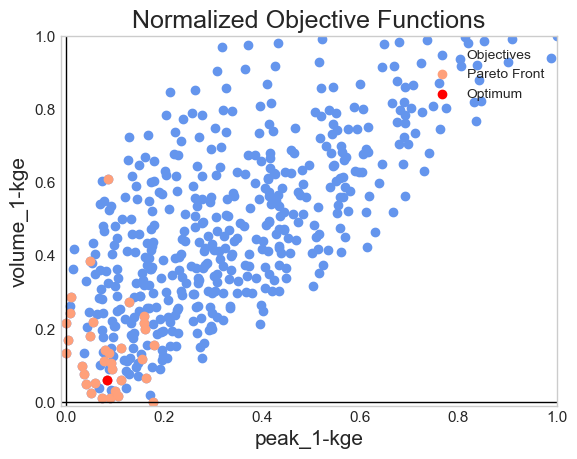

In [ ]:
cali_total_df_l.append(pareto_front_df)
cali_total_df_l.append(closest_point_df)
closest_point_df = closest_row_to_origin(pareto_front_df)
# Call the function for the first dataset and store the scatter object
scatter1 = objective_scatter_plot(objectives_df, objective1, objective2, color = 'cornflowerblue')
scatter2 = objective_scatter_plot(pareto_front_df, objective1, objective2, color='lightsalmon')
scatter3 = objective_scatter_plot(closest_point_df, objective1, objective2, color='r')
# Set axis labels and title
plt.ylabel(objective2, size = 15)
plt.xlabel(objective1, size = 15)
plt.title('Normalized Objective Functions', size = 18)
plt.xlim(-0.01, 1)
plt.ylim(-0.01, 1)
plt.grid()
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.tick_params(axis='both', labelsize=11, width=1.5)

# Create a legend for the scatter plots
plt.legend([scatter1, scatter2, scatter3], ['Objectives', 'Pareto Front', 'Optimum'], 
           scatterpoints=1, loc='upper right')

# Display the plot
plt.show()

# Save the dict to pickle

In [ ]:
# Define the path and filename
path = r'D:\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, 'cross_validation_cali_solution_dict.pickle')

# Save the dictionary as a pickle file
with open(filename, 'wb') as file:
    pickle.dump(cross_validation_dict, file)


# Load the dict to pickle

In [ ]:
# Define the path and filename
path = r'D:\Development\RESEARCH\Raanana\SWMM/'
filename = os.path.join(path, 'cross_validation_cali_solution_dict.pickle')

# Load the dictionary from the pickle file
with open(filename, 'rb') as file:
    cross_validation_dict = pickle.load(file)

In [ ]:
def observation_and_swmm_hydrograph(storm_df, date):
    """
    This function takes observation and SWMM model runoff and precipitation data and puts it in a hydrograph.
    Params:
     - storm_df: df, The DataFrame that includes the runoff and precipitation data
     - date: date of storm occurrence. Format: 'yyyy_mm_dd'
    Returns: a hydrograph plot for one subcatchment
    """
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(storm_df.index.strftime('%d/%m/%Y')[0], fontsize=20)

    y_obs_runoff = storm_df['OBS runoff [CMS]']
    y_rainfall = storm_df['rainfall [mm/h]']
    y_sim_runoff = storm_df['SWMM outflow [CMS]']

    ax1 = sns.lineplot(ax=ax, data=y_obs_runoff, color='g', label='Observed Discharge')
    ax2 = ax1.twinx()

    sns.lineplot(ax=ax2, data=y_rainfall, color='b', label='Rainfall', alpha=0.4)
    ax2.fill_between(storm_df.index, 0, y_rainfall, alpha=0.4, color='b')
    ax2.set_ylim(ymin=150, ymax=0)
    ax1.set_ylim(ymin=0, ymax=90)

    sns.lineplot(ax=ax, data=y_sim_runoff, color='r', label='Simulated Discharge')

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax1.set_ylabel('Discharge ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=15)

    # set x-axis label format to %d/%m %H
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax1.tick_params(axis='y', labelsize=18)
    ax2.tick_params(axis='y', labelsize=18)
    ax1.grid()

    # Adjust layout to ensure everything fits and add padding
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)  # Increase bottom padding

    return fig


In [ ]:
raanana_area = 13256.0 # KM

def calculate_runoff_coefficient(storm_df, catchment_area_m2):
    """
    Calculate the runoff coefficient from storm event data.

    Parameters:
    storm_df (pd.DataFrame): A dataframe with columns 'OBS runoff [CMS]', 'SWMM outflow [CMS]', and 'rainfall [mm/h]'.
    catchment_area_m2 (float): The catchment area in square meters.

    Returns:
    float: The total runoff coefficient for the event.
    """
    
    # Constants
    time_interval_sec = 300  # 5 minutes in seconds
    mm_to_m = 1  # Conversion factor from mm to meters

    # Calculate total runoff volume in m³ for the observed data (OBS runoff [CMS] * time interval)
    storm_df['Runoff Volume (m³)'] = storm_df['OBS runoff [CMS]'] * time_interval_sec

    # Convert rainfall from mm/h to volume over 5 minutes (m³) for the catchment area
    # First, convert mm/h to mm over 5 minutes, then to meters (m) by multiplying by mm_to_m
    storm_df['Rainfall Volume (m³)'] = (storm_df['rainfall [mm/h]'] / 12) * catchment_area_m2 * mm_to_m

    # Calculate the total runoff volume (m³) and total rainfall volume (m³)
    total_runoff_volume = storm_df['Runoff Volume (m³)'].sum()
    total_rainfall_volume = storm_df['Rainfall Volume (m³)'].sum()


    runoff_coefficient = total_runoff_volume / total_rainfall_volume

    return runoff_coefficient


In [ ]:
def plot_scientific_hydrograph(storm_df, date, dates_label_dict, save_path='None'):
    """
    Creates a publication-quality hydrograph plot combining observed/simulated discharge and rainfall data.
    
    Parameters:
    -----------
    storm_df : pd.DataFrame
        DataFrame containing runoff and precipitation data with columns:
        'OBS runoff [CMS]', 'SWMM outflow [CMS]', 'rainfall [mm/h]'
    date : str
        Date of storm occurrence in format 'yyyy_mm_dd'.
    dates_label_dict : dict
        Dictionary mapping dates (as keys) to label strings (as values) to display in the plot.
    save_path : str, optional
        Path to save the figure. If None, figure is only displayed.
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure object.
    """
    # Set style parameters
    plt.style.use('seaborn-whitegrid')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 1.0
    
    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    
    # Convert datetime index to hours from start
    start_time = storm_df.index[0]
    hours_from_start = [(t - start_time).total_seconds() / 3600 for t in storm_df.index]
    
    # Format date as DD/MM/YYYY
    date_str = f"{date[8:10]}/{date[5:7]}/{date[:4]}"
    
    # Plot discharge data
    ax1.plot(hours_from_start, storm_df['OBS runoff [CMS]'], 
             color='#000000', linewidth=2, label='Observed discharge')
    ax1.plot(hours_from_start, storm_df['SWMM outflow [CMS]'], 
             color='#CD5C5C', linewidth=2, label='Simulated discharge')
    
    # Plot rainfall data as bar plot (columns)
    ax2.bar(hours_from_start, storm_df['rainfall [mm/h]'], 
            color='#0000FF', alpha=0.6, label='Rainfall', width=0.1)
    
    # Set labels
    ax1.set_xlabel('Time [hours]', fontsize=22)
    ax1.set_ylabel('Discharge [m$^3$ s$^{-1}$]', fontsize=22, labelpad=5)
    ax2.set_ylabel('Rainfall [mm h$^{-1}$]', fontsize=22, labelpad=5)
    
    # Adjust label positions
    ax1.yaxis.set_label_coords(-0.05, 0.3)  # Move discharge label closer to axis
    ax2.yaxis.set_label_coords(1.05, 0.7)  # Move rainfall label closer to axis
    
    # Set axis limits
    ax1.set_ylim(0, 100)  # Fixed discharge range
    ax2.set_ylim(180, 0)  # Fixed rainfall range (inverted)
    
    # Set specific tick locations
    ax1.set_yticks([0, 10, 20, 30, 40])  # Discharge ticks
    ax2.set_yticks([0, 20, 40, 60, 80])  # Rainfall ticks
    
    # Set x-axis ticks to show every 6 hours
    max_hours = max(hours_from_start)
    tick_positions = np.arange(0, max_hours + 6, 3)
    ax1.set_xticks(tick_positions)
    ax1.set_xlim(0, max_hours)
    
    
        # Make the frame darker
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Format ticks and grid
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', labelsize=24, width=1)
        ax.grid(True)
    
    # Create a new axes for the title and label to ensure they're aligned
    title_ax = fig.add_axes([0, 0, 1, 1], frameon=False)
    title_ax.set_axis_off()
    
    # Add date and label in the same vertical position
    if date in dates_label_dict:
        label_text = dates_label_dict[date]
        # Add label on the left
        title_ax.text(0.05, 0.95, label_text, fontsize=32, fontweight='bold')
        # Add date in the center
        title_ax.text(0.5, 0.95, date_str, fontsize=32, ha='center')
    else:
        # If no label, just add the date in the center
        title_ax.text(0.5, 0.95, date_str, fontsize=30, ha='center')
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines1 + lines2, labels1 + labels2,
#               loc='center left', fontsize=20, framealpha=0.5)
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
    
    return fig

In [ ]:
## Define hydrograph fig labals for specific evetns
# dates_label_dict = {'2013_01_06': '(a)', '2015_10_28': '(b)', '2016_01_08': '(c)', '2020_01_19': '(d)'}   ## paper
dates_label_dict = {'2012_01_13': '(a)', '2016_01_08': '(b)', '2018_01_25': '(c)', '2019_12_13': '(d)'}   ## SA

In [ ]:
cali_total_df_l[4]
2

Factors                     Width                        0.7
                            IMP                          1.0
                            Storage                        7
                            N                            1.0
                            PCT_ZERO                     1.0
                                                    ...     
volume objective functions  volume_rmsd         41318.538834
                            volume_bias          8567.895891
                            volume_mad          29465.797371
                            volume_r_squared        0.735682
                            volume_1-kge            0.172678
Name: 107, Length: 95, dtype: object

# STEP 4 - Run Validation Storms

2012_01_13


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2012_01_13/Final.inp:   0%|          | …

2012_01_13 68.29635752398735
2013_01_06


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2013_01_06/Final.inp:   0%|          | …

2013_01_06 91.35188405382844
2014_12_14


...

2019_12_13 32.55673149781069
2019_12_27


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2019_12_27/Final.inp:   0%|          | …

2019_12_27 26.1435164950517
2020_01_19


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/2020_01_19/Final.inp:   0%|          | …

2020_01_19 79.38691244518365


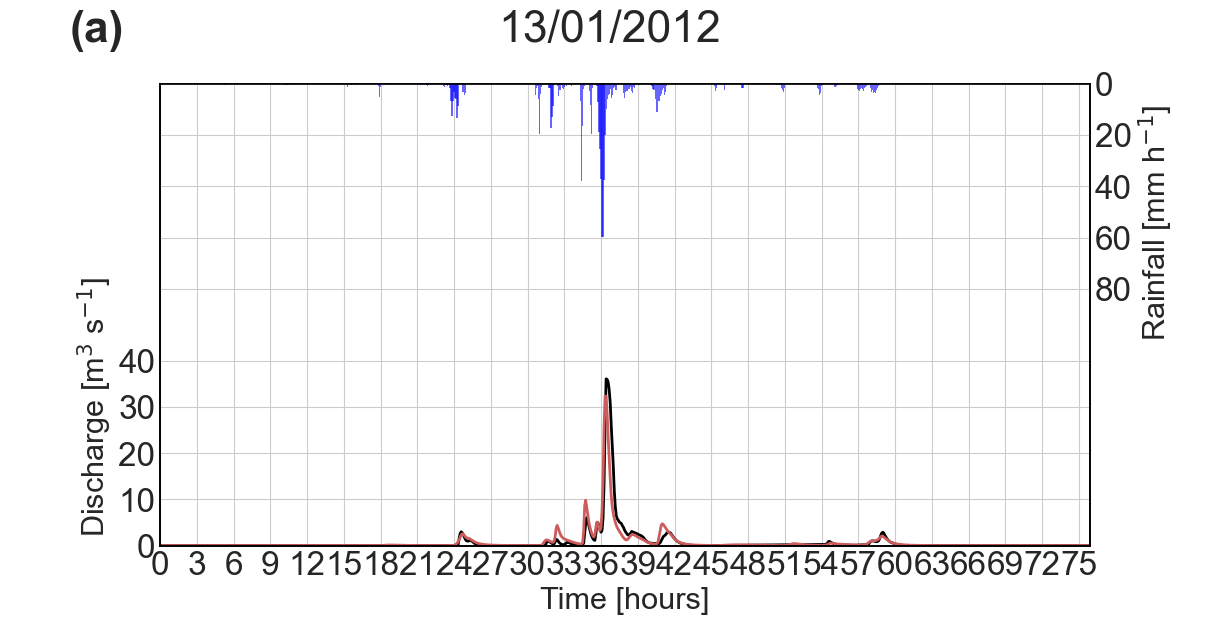

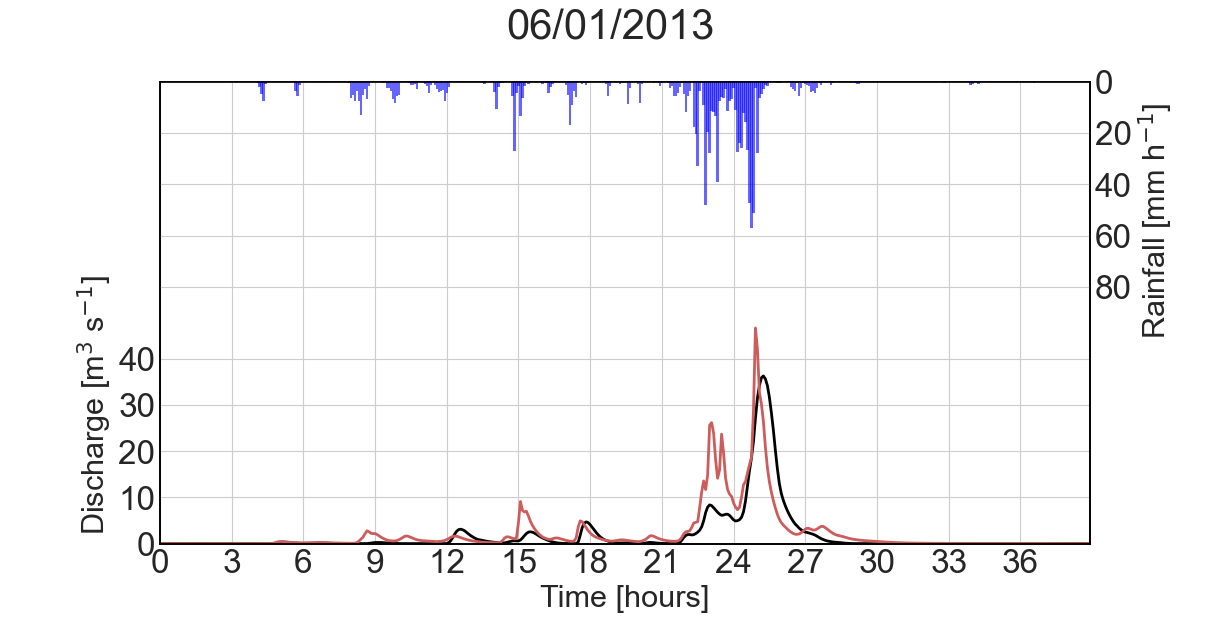

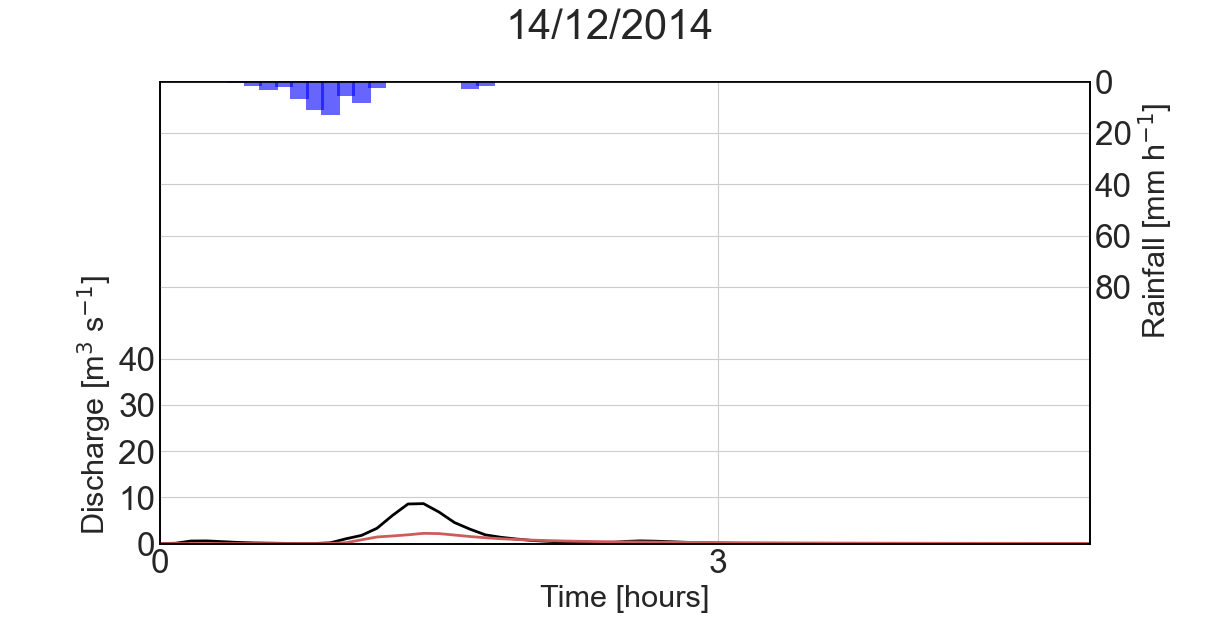

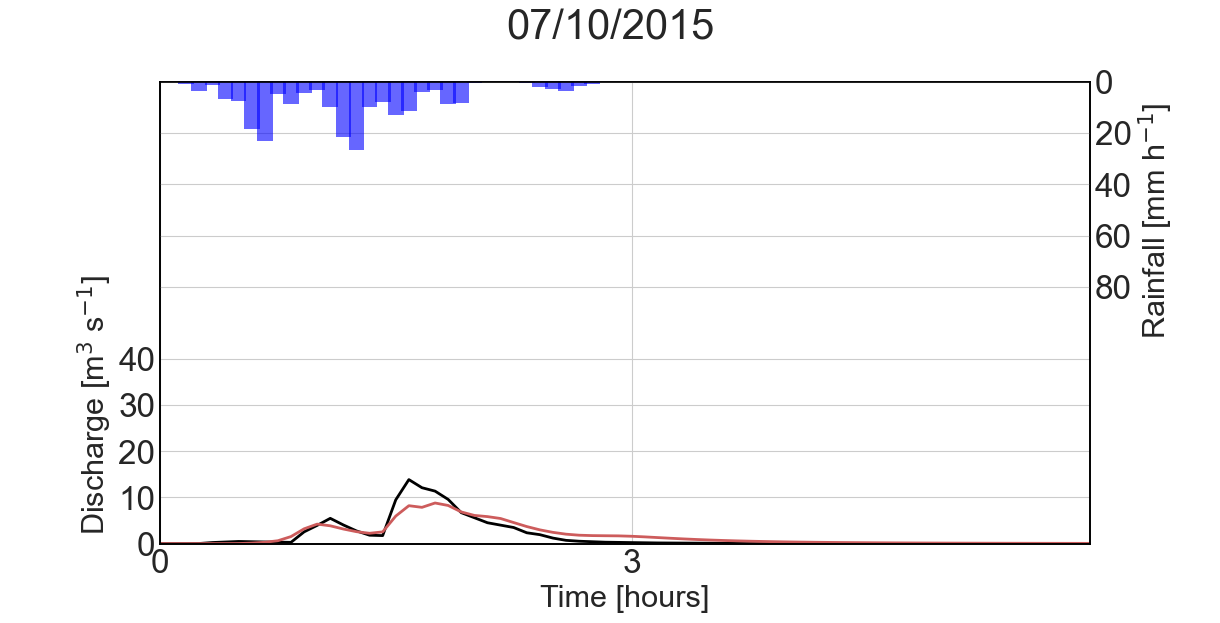

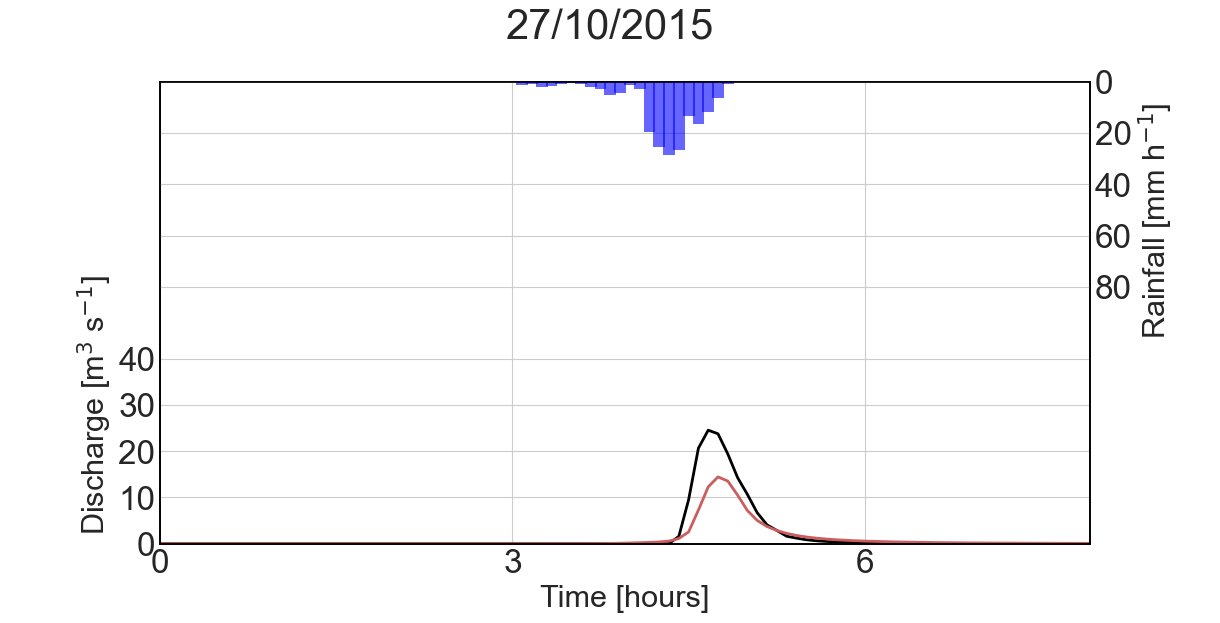

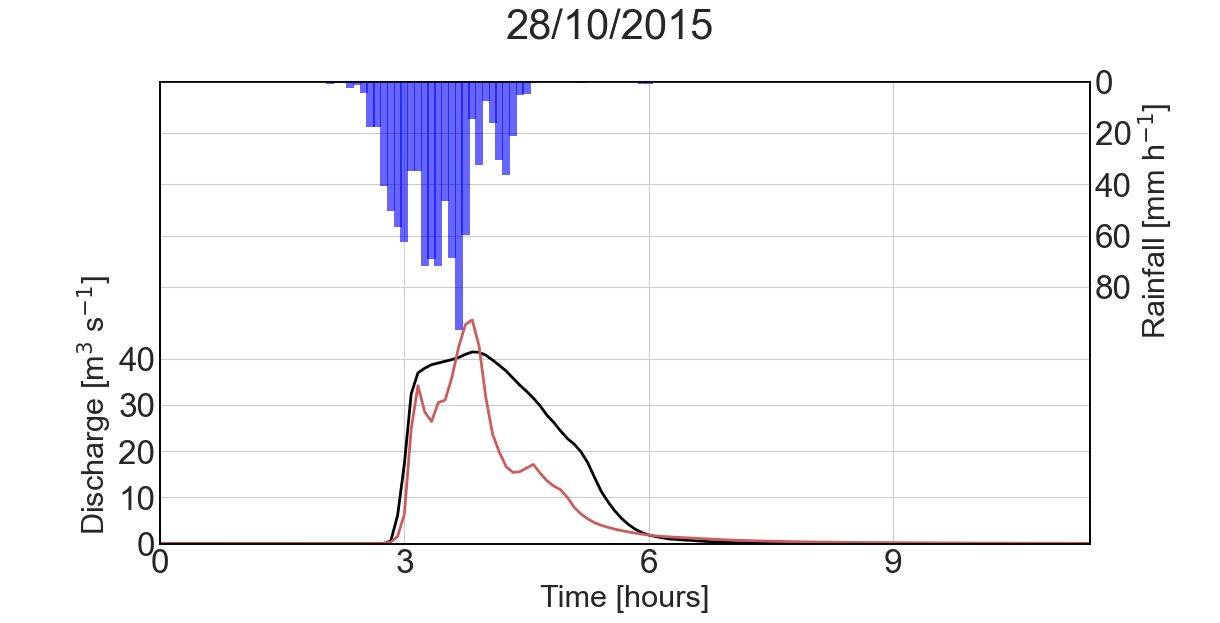

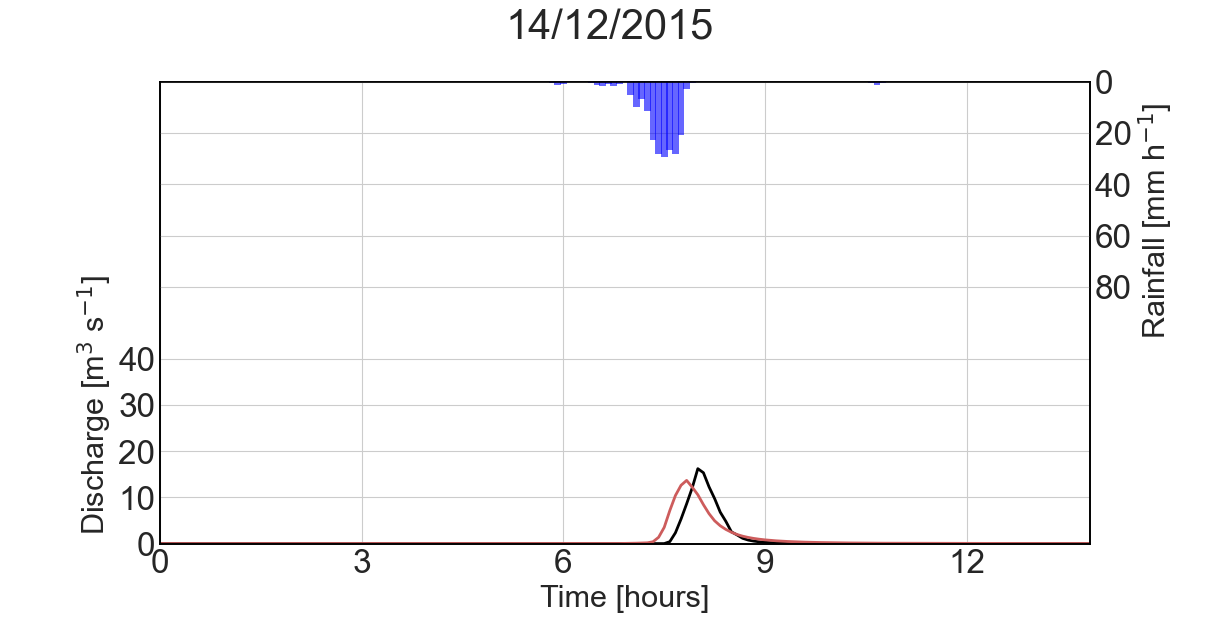

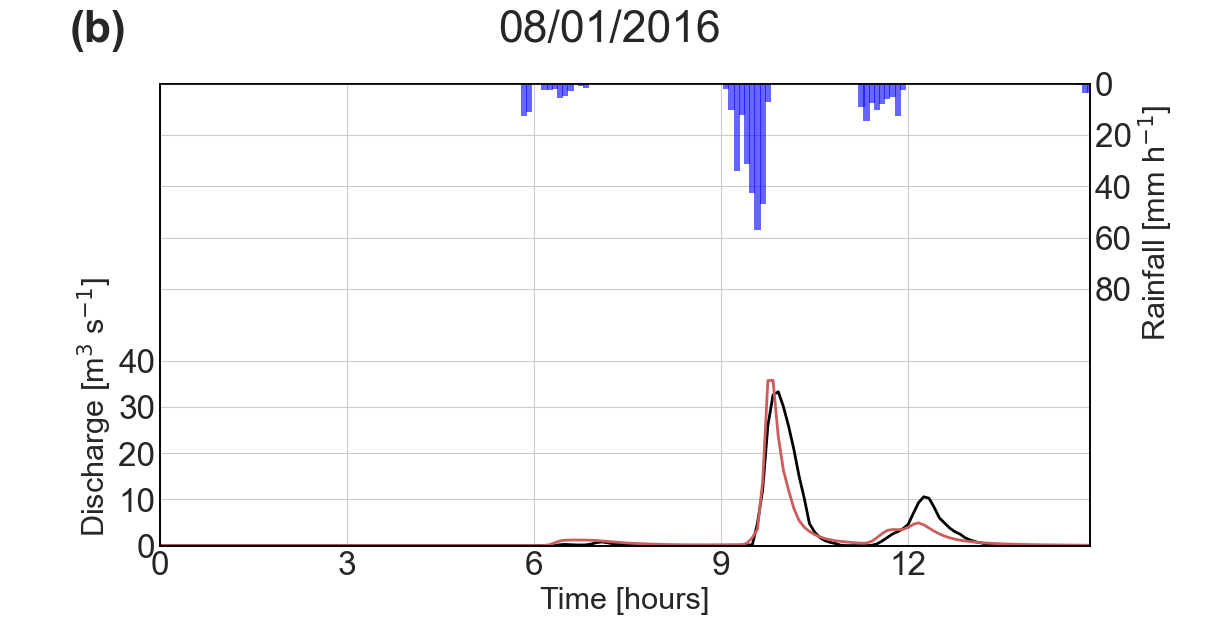

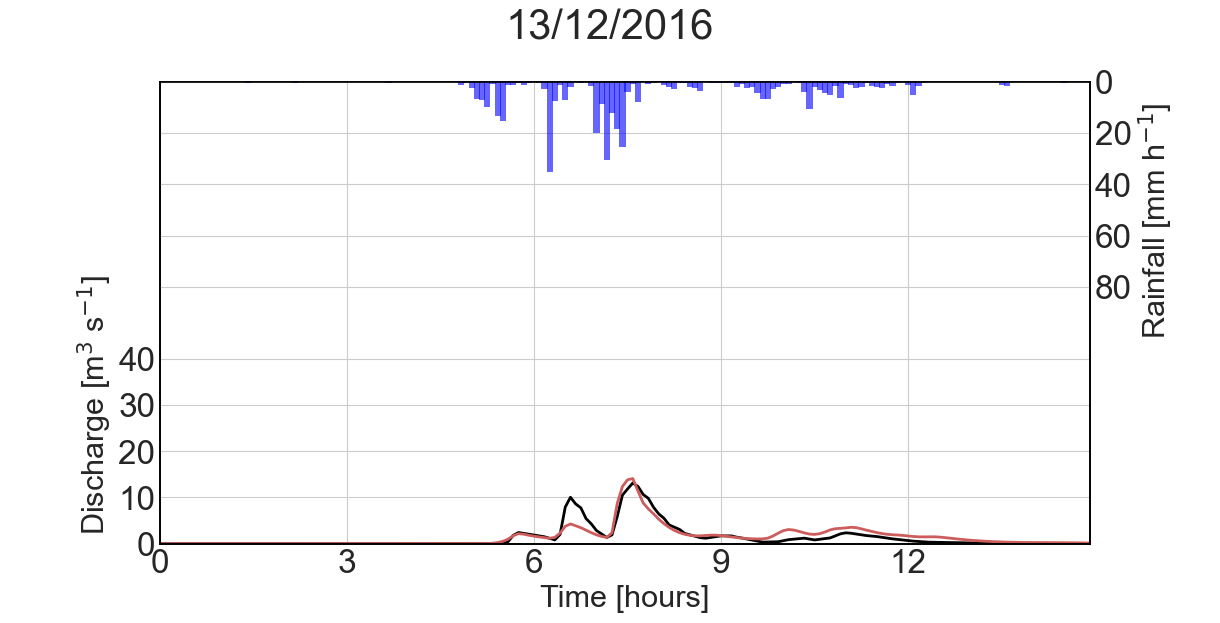

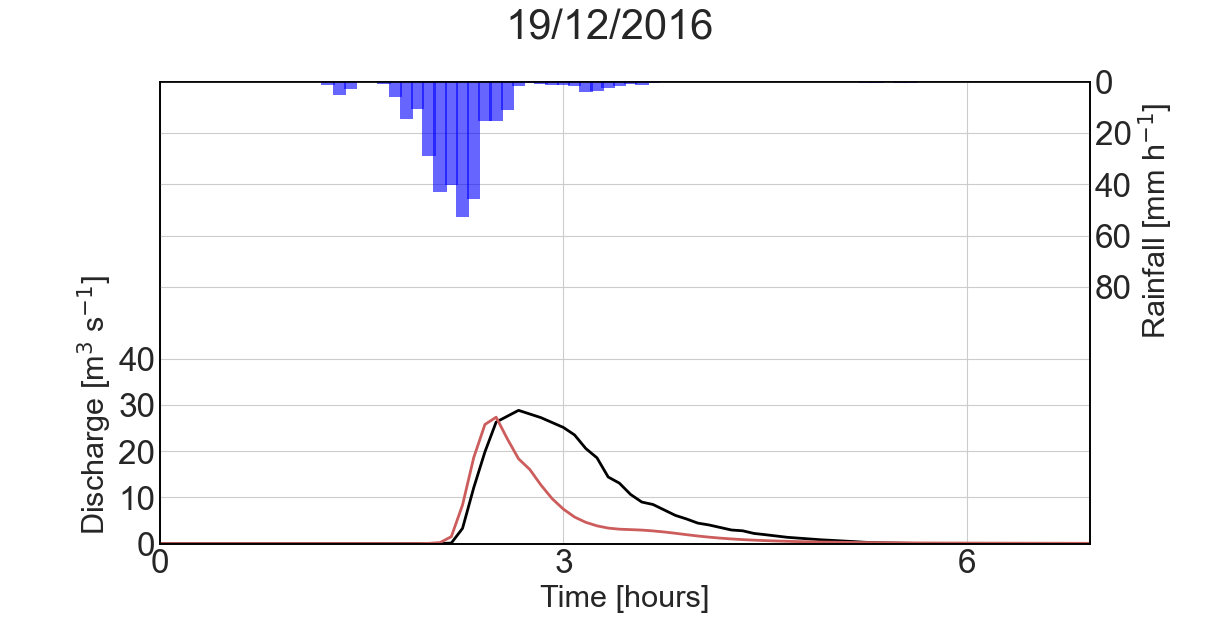

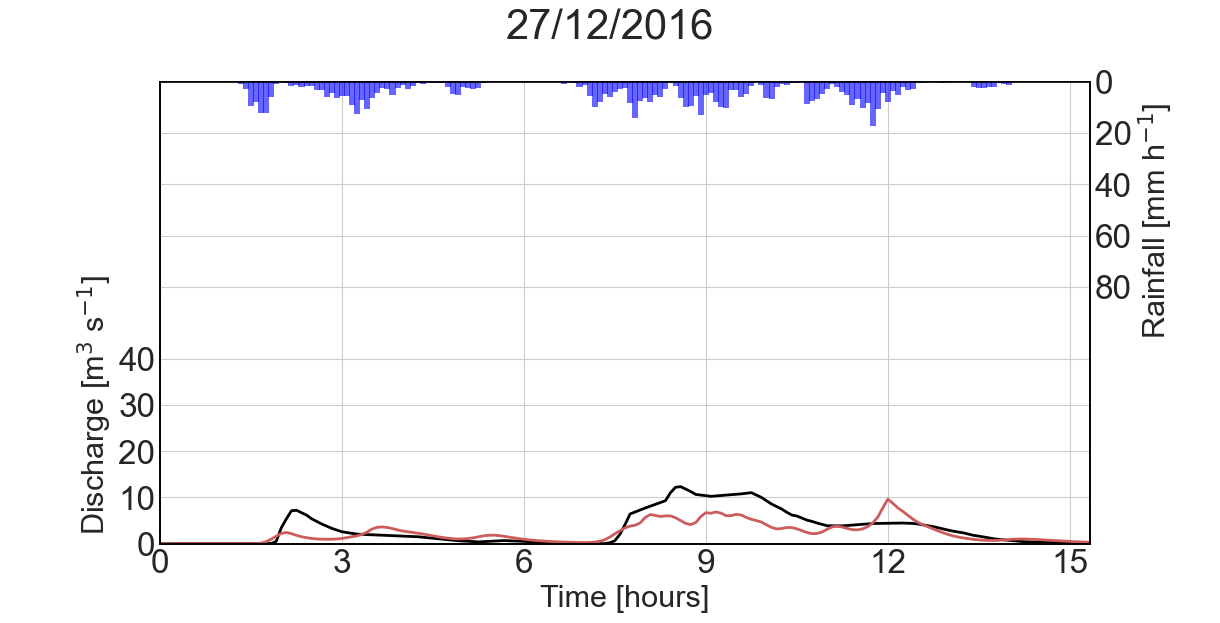

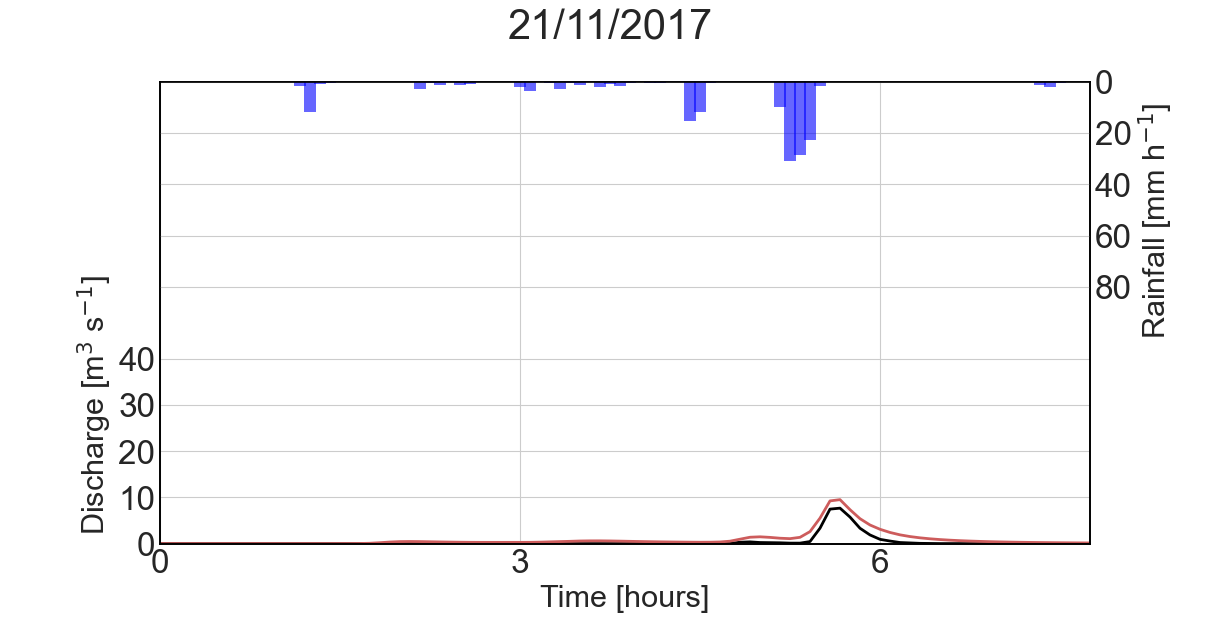

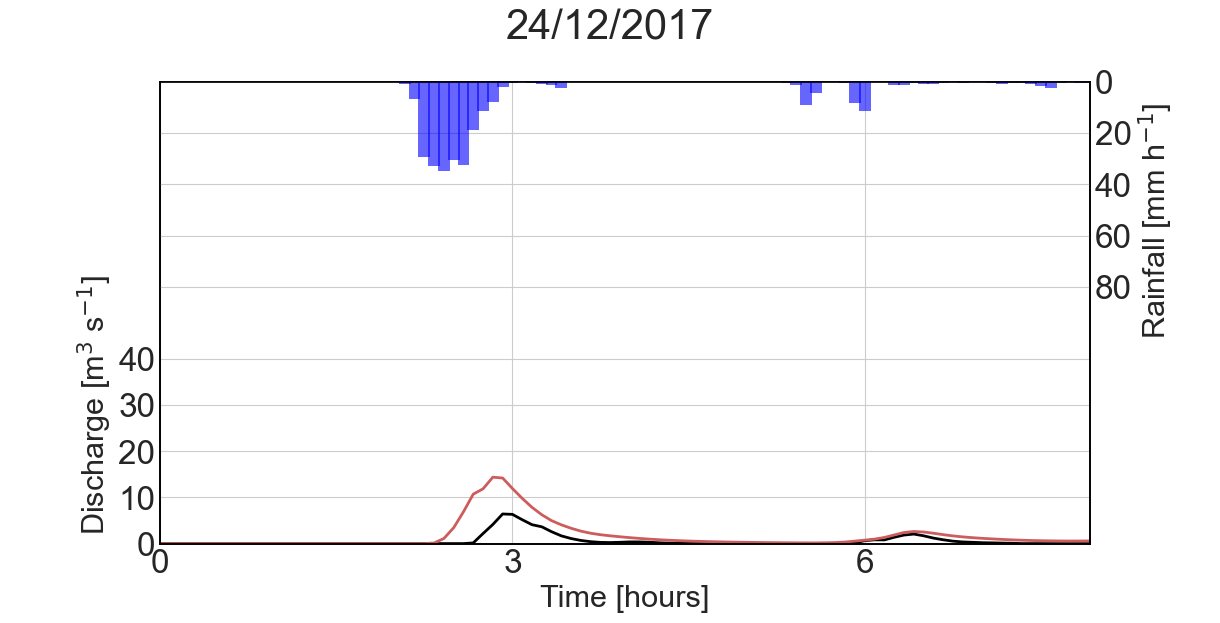

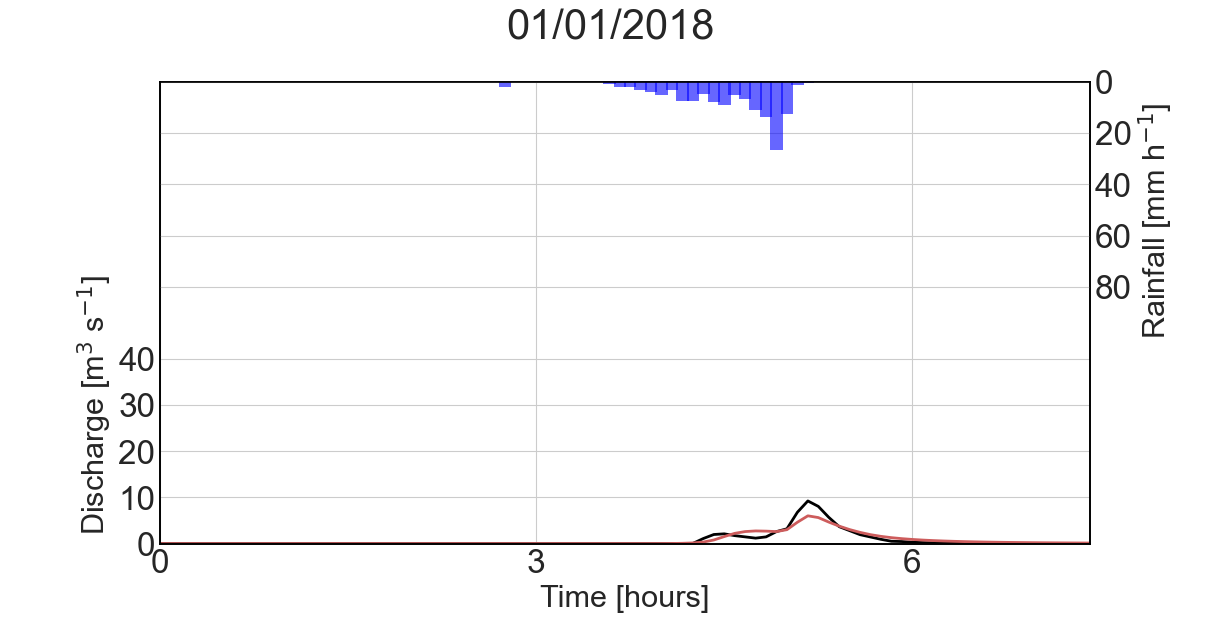

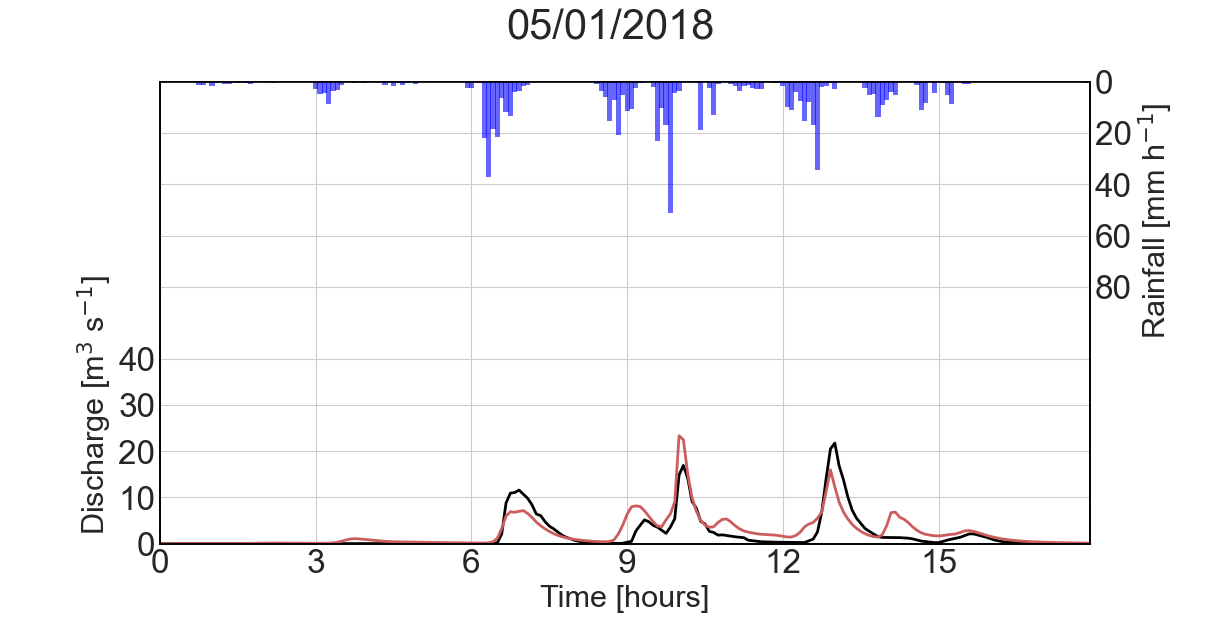

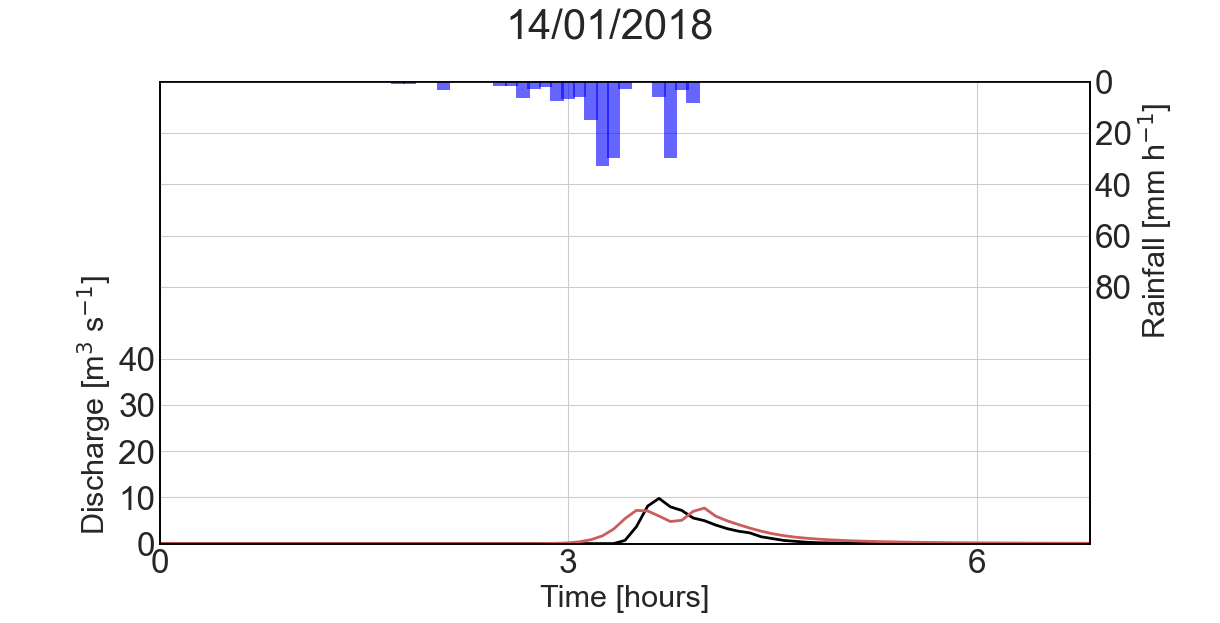

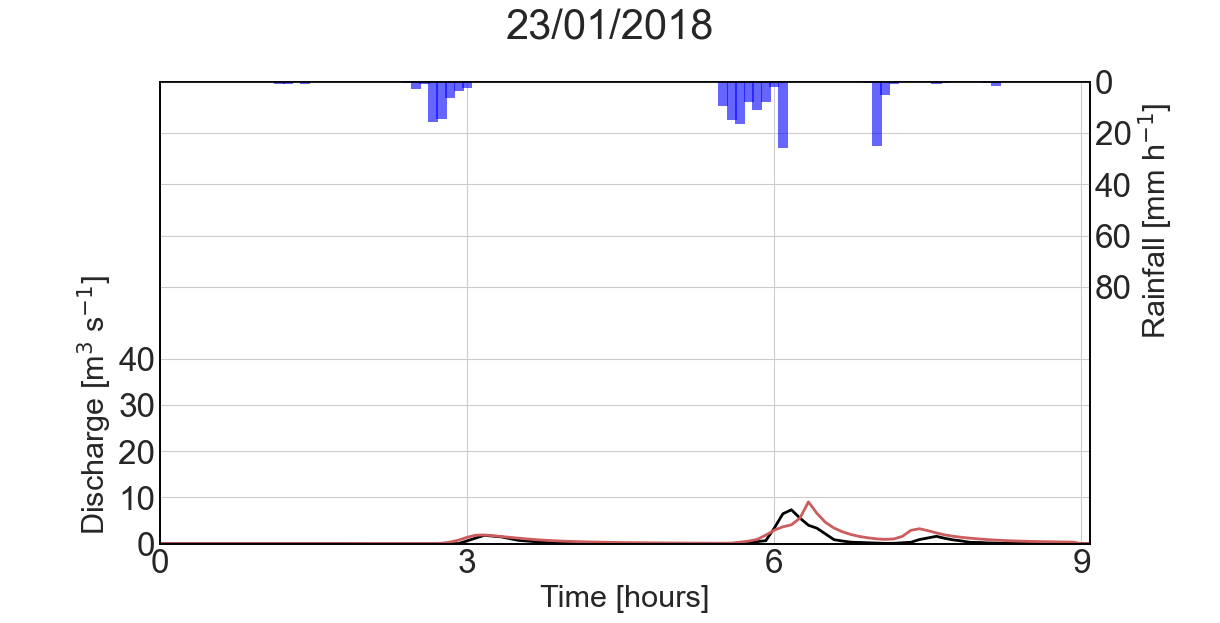

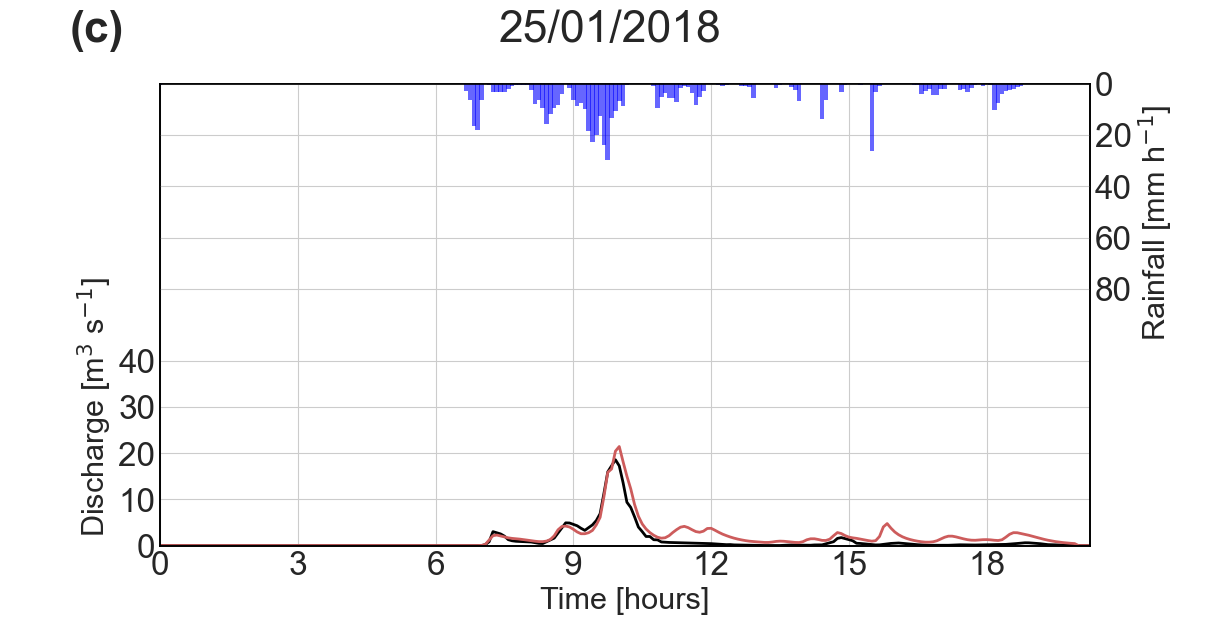

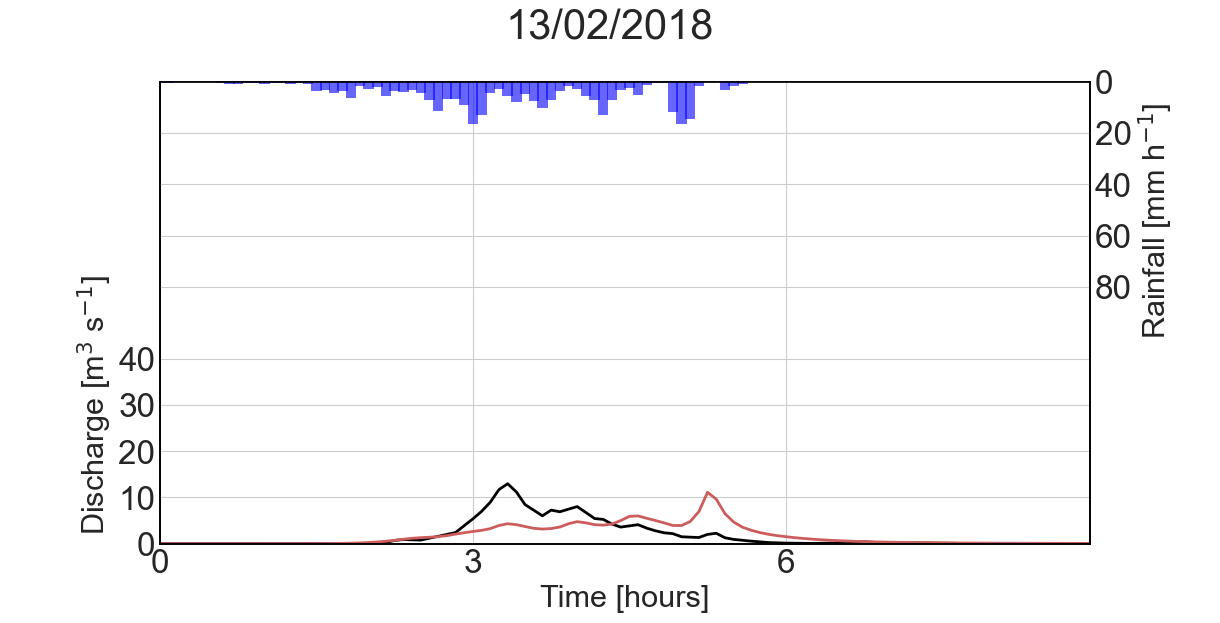

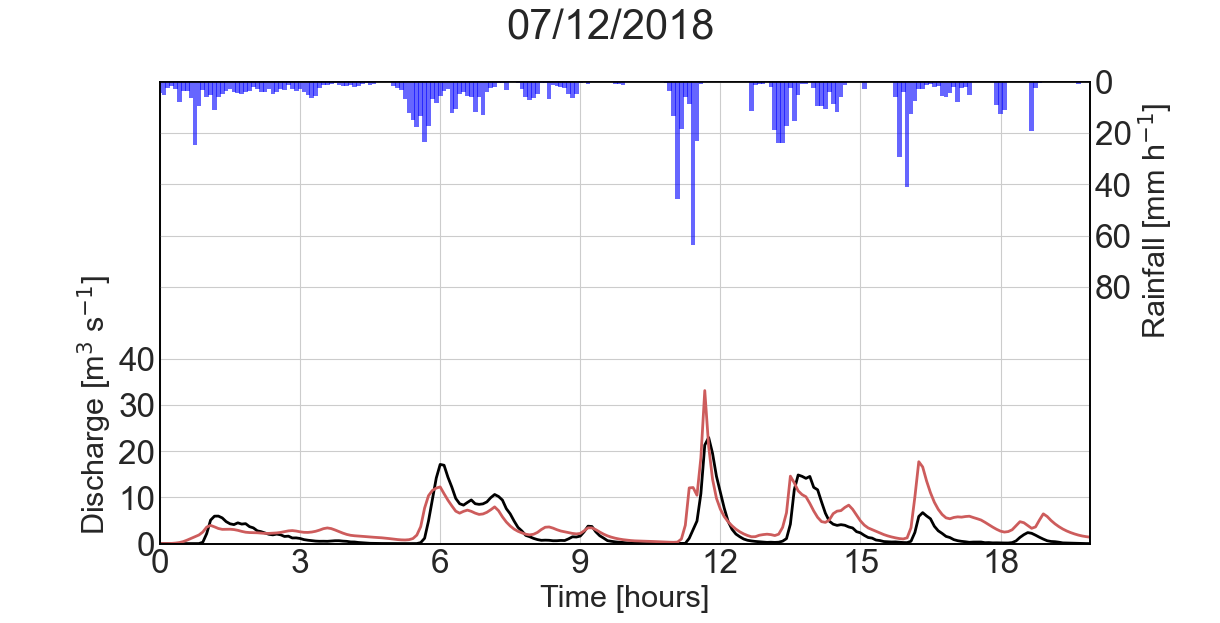

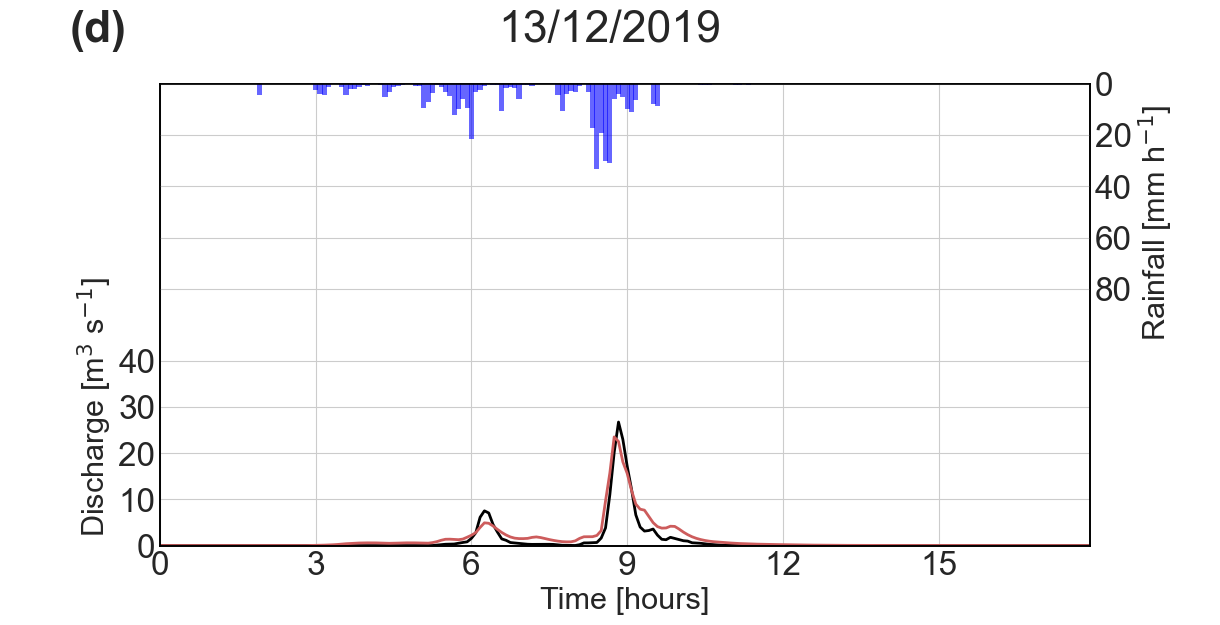

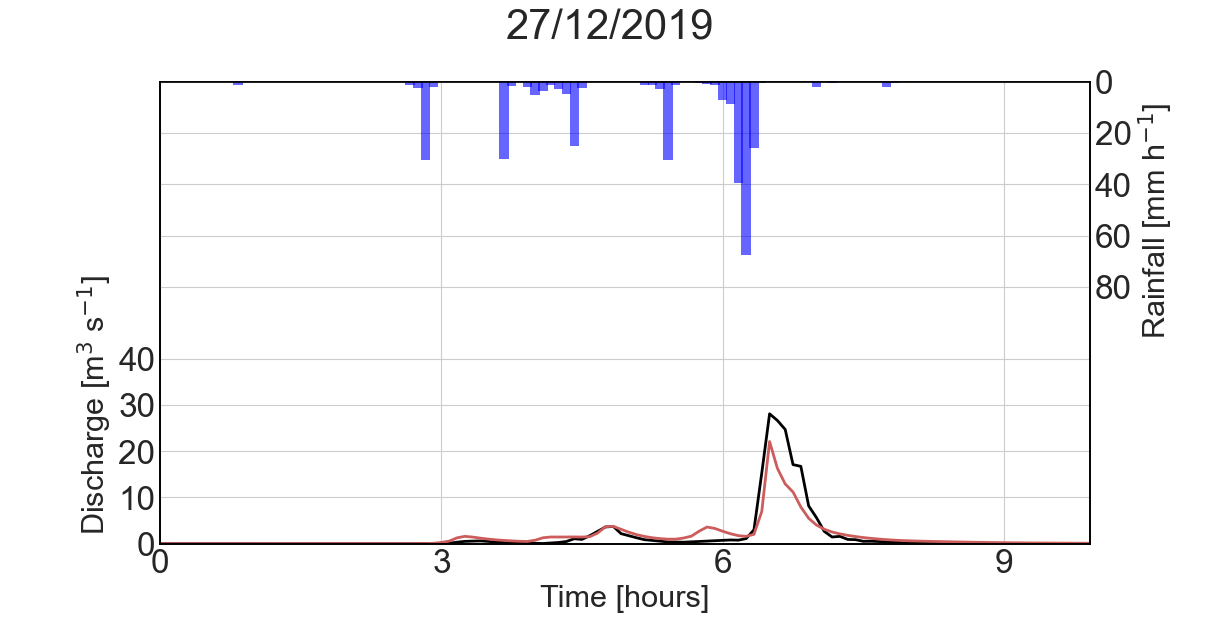

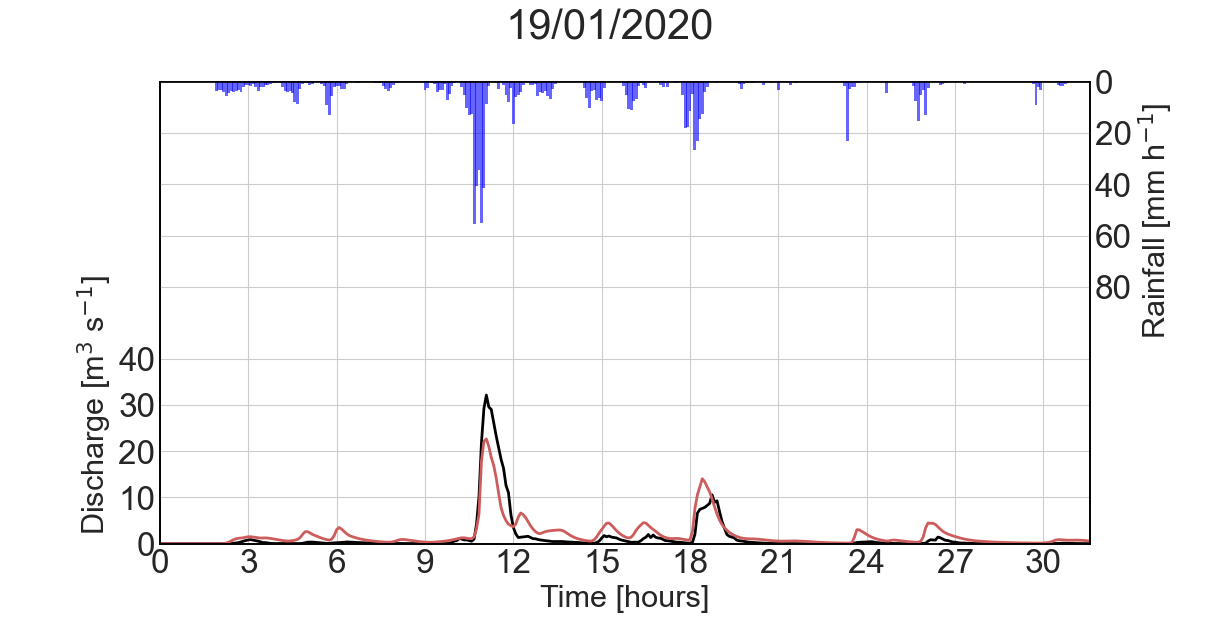

In [ ]:
MAIN_PATH = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation/"

# Initialize lists
imp_factor_l = [] ; width_factor_l = [] ; storage_factor_l = [] ; pct_zero_factor_l = [] ; n_factor_l =[] ; cn_factor_l =[]
vali_results_df_l =[] ; hydrograph_df_l = [] ; swmm_runoff_l = [] 
swmm_max_outflow_time_l =[] ; swmm_total_outflow_l = [] ; swmm_max_outflow_l = [] 
pct_routed_factor_l = [] ; evap_factor_l = [] 
runoff_coeff_l = []  # List to store runoff coefficients for each date
rain_intensity_metrics_l = []  # List to store rainfall intensity metrics for each date

# Initial parameter values
width_initial_values = np.array([2470, 2800, 2800, 1890, 1160, 2840, 2660, 2000, 1140, 1400, 540, 2200, 4160, 1070, 1310, 1310, 1200, 1440, 1400, 1400, 1520, 1850, 1740, 2504, 980, 1900, 2140, 950])
curve_no_initial_values = np.array([39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39, 39])
pct_zero_initial_values = np.array([30, 50, 50, 50, 50, 50, 50, 50, 30, 50, 50, 30, 30, 50, 30, 50, 50, 50, 50, 50, 50, 60, 50, 50, 50, 60, 60, 30])

count = 0
obs_hydrograph_df = pd.DataFrame()
i = 0

# Loop through each file
for filename in os.listdir(MAIN_PATH):
    # Load best multi-objective solution factors
    width_factor = cali_total_df_l[4][('Factors', 'Width')]
    imp_factor = cali_total_df_l[4][('Factors', 'IMP')]
    storage_factor = cali_total_df_l[4][('Factors', 'Storage')]
    n_factor = cali_total_df_l[4][('Factors', 'N')]
    pct_zero_factor = cali_total_df_l[4][('Factors', 'PCT_ZERO')]
    cn_factor = cali_total_df_l[4][('Factors', 'CN')]
    pct_routed_factor = cali_total_df_l[4][('Factors', 'PCT_ROUTED')]
    evap_factor = cali_total_df_l[4][('Factors', 'EVAP')]

    date = filename
    OBS_FILE = date
    print(date)
    SIM_PATH = os.path.join(MAIN_PATH, date + '/')

    # Load observed runoff data
    obs_runoff_df = data_5min_interpolate(load_runoff_obs_to_df(SIM_PATH + OBS_FILE))

    # Load the SWMM input and dictionary files
    INP_FILE = r"raanana_28subcatchments.inp"
    inp = read_inp_file(SIM_PATH + INP_FILE)
    subcatchment_d = dict(inp[sections.SUBCATCHMENTS])
    infiltration_d = dict(inp[sections.INFILTRATION])
    subareas_d = dict(inp[sections.SUBAREAS])
    timesereies_d = dict(inp[sections.TIMESERIES])

    # Update factors in the input file
    update_imperviousness_with_factor(subcatchment_d, imp_factor)
    update_storage_with_factor(subareas_d, storage_factor)
    update_width_with_factor(subcatchment_d, width_factor, width_initial_values)
    update_n_with_factor(subareas_d, n_factor)
    update_pct_zero_with_factor(subareas_d, pct_zero_factor, pct_zero_initial_values)
    update_curve_num_with_factor(infiltration_d, cn_factor, curve_no_initial_values)
    update_pct_routed_with_factor(subareas_d, 'PERVIOUS', pct_routed_factor)
    inp['EVAPORATION']['CONSTANT'] = evap_factor

    # Run the SWMM simulation
    file_name = 'Final'
    inp.write_file(SIM_PATH + file_name + '.inp')
    swmm5_run(SIM_PATH + file_name + '.inp', progress_size=1)

    # Load the simulation output
    OUT_FILE = file_name + '.out'
    sim_df = load_sim_to_df(SIM_PATH + OUT_FILE)

    # Concatenate observed and simulated data
    storm_df = pd.concat([obs_runoff_df, sim_df], axis=1)
    storm_df[storm_df < 0] = 0
    storm_df = storm_df.fillna(0)

    # Plot the observed and SWMM hydrograph
#     fig = observation_and_swmm_hydrograph(storm_df, date)
#     fig.savefig(os.path.join(r'D:\Development\RESEARCH\Raanana\figures\28_catchments_cross_validation\FINAL_MODEL/', date + '.png'), dpi=900)

    
    plot_scientific_hydrograph(storm_df, date, dates_label_dict, 
        save_path=os.path.join(r'D:\Development\RESEARCH\Raanana\figures\28_catchments_cross_validation\FINAL_MODEL', f"{date}.png"))

    
    # Calculate statistics using the new simulation_stat function
    (swmm_total_outflow, swmm_max_outflow, swmm_max_outflow_time,
     max_10min_intensity, max_20min_intensity, max_30min_intensity, max_60min_intensity,
     max_120min_intensity, max_240min_intensity, max_360min_intensity,
     max_720min_intensity, max_1440min_intensity, total_rain) = simulation_stat(storm_df)

    # Calculate runoff coefficient
    runoff_coeff = calculate_runoff_coefficient(storm_df, raanana_area)
    runoff_coeff_l.append(runoff_coeff)

    # Append values to lists
    imp_factor_l.append(imp_factor)
    width_factor_l.append(width_factor)
    storage_factor_l.append(storage_factor)
    n_factor_l.append(n_factor)
    pct_zero_factor_l.append(pct_zero_factor)
    cn_factor_l.append(cn_factor)
    pct_routed_factor_l.append(pct_routed_factor)
    evap_factor_l.append(evap_factor)
    swmm_total_outflow_l.append(swmm_total_outflow)
    swmm_max_outflow_l.append(swmm_max_outflow)
    swmm_max_outflow_time_l.append(swmm_max_outflow_time)

    # Create DataFrame for validation results
    factor = pd.DataFrame(columns=pd.MultiIndex.from_product([['Factors'],
                                                              ['Width', 'IMP', 'Storage', 'N', 'PCT_ZERO', 'CN', 'PCT_ROUTED', 'EVAP']]))
    vali_results_df = pd.DataFrame(columns=pd.MultiIndex.from_product([[date],
                                                                      ['Total Volume', 'Max Runoff', 'Max Runoff Time', 'Runoff Coefficient', 
                                                                       'Max 10-min Intensity', 'Max 20-min Intensity', 'Max 30-min Intensity', 
                                                                       'Max 60-min Intensity', 'Max 120-min Intensity', 'Max 240-min Intensity', 
                                                                       'Max 360-min Intensity', 'Max 720-min Intensity', 'Max 1440-min Intensity', 
                                                                       'Total Rainfall']]))

    vali_results_df = pd.concat([factor, vali_results_df], axis=0)

    # Store the factors in DataFrame
    vali_results_df[('Factors', 'IMP')] = imp_factor_l
    vali_results_df[('Factors', 'Width')] = width_factor_l
    vali_results_df[('Factors', 'Storage')] = storage_factor_l
    vali_results_df[('Factors', 'N')] = n_factor_l
    vali_results_df[('Factors', 'PCT_ZERO')] = pct_zero_factor_l
    vali_results_df[('Factors', 'CN')] = cn_factor_l
    vali_results_df[('Factors', 'PCT_ROUTED')] = pct_routed_factor_l
    vali_results_df[('Factors', 'EVAP')] = evap_factor_l

    # Store the results in the DataFrame
    vali_results_df[(date, 'Total Volume')] = swmm_total_outflow_l
    vali_results_df[(date, 'Max Runoff')] = swmm_max_outflow_l
    vali_results_df[(date, 'Max Runoff Time')] = swmm_max_outflow_time_l
    vali_results_df[(date, 'Runoff Coefficient')] = runoff_coeff_l

    # Store the rainfall intensity metrics in the DataFrame
    vali_results_df[(date, 'Max 10-min Intensity')] = max_10min_intensity
    vali_results_df[(date, 'Max 20-min Intensity')] = max_20min_intensity
    vali_results_df[(date, 'Max 30-min Intensity')] = max_30min_intensity
    vali_results_df[(date, 'Max 60-min Intensity')] = max_60min_intensity
    vali_results_df[(date, 'Max 120-min Intensity')] = max_120min_intensity
    vali_results_df[(date, 'Max 240-min Intensity')] = max_240min_intensity
    vali_results_df[(date, 'Max 360-min Intensity')] = max_360min_intensity
    vali_results_df[(date, 'Max 720-min Intensity')] = max_720min_intensity
    vali_results_df[(date, 'Max 1440-min Intensity')] = max_1440min_intensity
    vali_results_df[(date, 'Total Rainfall')] = total_rain

    # Merge DataFrames and reset for next iteration
    vali_results_df_l.append(vali_results_df)

    # Reset lists for each date iteration
    imp_factor_l = [] ; width_factor_l = [] ; storage_factor_l = [] ; pct_zero_factor_l = [] ; n_factor_l =[] ; cn_factor_l =[]
    swmm_runoff_l = [] ; swmm_max_outflow_time_l =[] ; swmm_total_outflow_l = [] ; swmm_max_outflow_l = [] ;
    pct_routed_factor_l = [] ; evap_factor_l = [] ; runoff_coeff_l = []
    print(date, total_rain)
# After the loop ends, process the final merged results
final_vali_results_df = pd.concat(vali_results_df_l, axis=1)



In [ ]:
vali_results_df[(date, 'Total Rainfall')]

0    79.386912
Name: (2020_01_19, Total Rainfall), dtype: float64

# STEP 5 - PLOT
## scatter plots

In [ ]:
def calculate_objectives(observed, simulated):
    """
    Calculate the Nash-Sutcliffe Efficiency (NSE), Root Mean Square Deviation (RMSD), bias, Mean Absolute Deviation (MAD), and R-squared (R^2) between observed and simulated data.

    Parameters:
    observed (pandas.core.series.Series): Series containing the observed data.
    simulated (pandas.core.series.Series): Series containing the simulated data.

    Returns:
    nse (float): Nash-Sutcliffe Efficiency (NSE) value.
    rmsd (float): Root Mean Square Deviation (RMSD) value.
    bias (float): Bias value.
    mad (float): Mean Absolute Deviation (MAD) value.
    r_squared (float): R-squared (R^2) value.
    """
    if not isinstance(observed, np.ndarray):
        observed = observed.to_numpy()
    if not isinstance(simulated, np.ndarray):
        simulated = simulated.to_numpy()

    kge_tuple = he.evaluator(he.kge, simulated, observed)
    kge = kge_tuple[0]
    
    nse_tuple = he.evaluator(he.nse, simulated, observed)
    nse = nse_tuple[0]  
    
    rmsd = np.sqrt(np.mean((observed - simulated) ** 2))
    bias = np.mean(simulated - observed)
    mad = np.mean(np.abs(simulated - observed))

    observed = observed.flatten()  # Flatten the observed array to 1D
    simulated = simulated.flatten()  # Flatten the simulated array to 1D

    pearson_r = scipy.stats.pearsonr(observed, simulated)
    r_squared = pearson_r[0]**2
    
    objectives = {
        'kge': kge,
        'nse': nse,
        'rmsd': rmsd,
        'bias': bias,
        'mad': mad,
        'r_squared': r_squared
    }
    
    return objectives

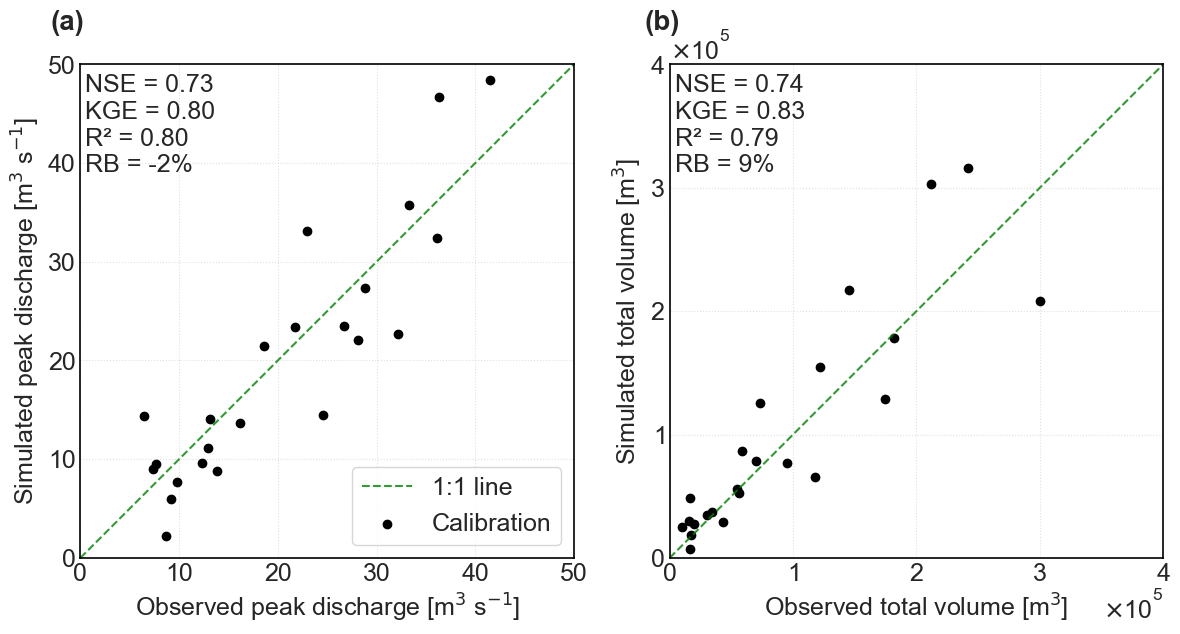

In [ ]:
def calculate_objectives(observed, simulated):
    """
    Calculate objective functions between observed and simulated data.
    """
    if not isinstance(observed, np.ndarray):
        observed = observed.to_numpy()
    if not isinstance(simulated, np.ndarray):
        simulated = simulated.to_numpy()
    
    kge_tuple = he.evaluator(he.kge, simulated, observed)
    kge = kge_tuple[0]
    
    nse_tuple = he.evaluator(he.nse, simulated, observed)
    nse = nse_tuple[0]  
    
    rmsd = np.sqrt(np.mean((observed - simulated) ** 2))
    bias = np.mean(simulated - observed)
    mad = np.mean(np.abs(simulated - observed))
    
    rel_bias = (np.mean(simulated - observed)/np.mean(observed))*100
    rel_rmsd = ((np.sqrt(np.mean((observed - simulated) ** 2)))/np.mean(observed))*100
    
    observed = observed.flatten()
    simulated = simulated.flatten()
    pearson_r = scipy.stats.pearsonr(observed, simulated)
    r_squared = pearson_r[0]**2
    
    return {
        'kge': kge,
        'nse': nse,
        'rmsd': rmsd,
        'bias': bias,
        'rel_bias': rel_bias,
        'rel_rmsd': rel_rmsd,        
        'mad': mad,
        'r_squared': r_squared
    }

# Define standardized font properties
TITLE_FONT = {'fontsize': 18, 'fontweight': 'bold'}
LABEL_FONT = {'fontsize': 18, 'fontweight': 'normal'}
TICK_FONT = {'labelsize': 18}
STATS_FONT = {'fontsize': 18, 'fontweight': 'normal'}
SUBPLOT_LABEL_FONT = {'fontsize': 20, 'fontweight': 'bold'}

def format_statistics(objectives):
    """Format statistical metrics with consistent notation."""
    return '\n'.join([
        f'NSE = {objectives["nse"]:.2f}',
        f'KGE = {objectives["kge"][0]:.2f}',
        f'R² = {objectives["r_squared"]:.2f}',
        f'RB = {objectives["rel_bias"]:.0f}%'  # Changed to use rel_bias and display as percentage
    ])

# Apply rounding to factor columns
factors_cols = [('Factors', 'IMP'), ('Factors', 'Storage'), ('Factors', 'Width'), 
                ('Factors', 'N'), ('Factors', 'PCT_ZERO'), ('Factors', 'PCT_ROUTED'), 
                ('Factors', 'EVAP')]
cali_total_df[factors_cols] = cali_total_df[factors_cols].apply(lambda x: x.round(2))

# Selecting the OPTIMUM FACTORS
imp_factor, storage_factor, width_factor, n_factor, pct_zero_factor, pct_routed_factor, evap_factor = [
    (cali_total_df_l[4][col].round(2)) for col in factors_cols]

cons_factors_df = cali_total_df.loc[
    (cali_total_df.loc[:, ('Factors', 'IMP')] == imp_factor) &
    (cali_total_df.loc[:, ('Factors', 'Storage')] == storage_factor) &
    (cali_total_df.loc[:, ('Factors', 'Width')] == width_factor) &
    (cali_total_df.loc[:, ('Factors', 'N')] == n_factor) &
    (cali_total_df.loc[:, ('Factors', 'PCT_ZERO')] == pct_zero_factor) &
    (cali_total_df.loc[:, ('Factors', 'PCT_ROUTED')] == pct_routed_factor) &
    (cali_total_df.loc[:, ('Factors', 'EVAP')] == evap_factor)]

# Calibration data: Peak runoff values
cali_max_obs_runoff = cali_obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
cali_max_swmm_runoff = cons_factors_df.loc[:, pd.IndexSlice[:, ['Max Runoff']]].values.flatten()

# Set figure properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.0
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Peak flow calibration
x_min_limit = 0; x_max_limit = 50; y_min_limit = 0; y_max_limit = 50
axs[0].scatter(cali_max_obs_runoff, cali_max_swmm_runoff, color='black', label='Calibration')
axs[0].plot([x_min_limit, x_max_limit], [x_min_limit, x_max_limit], color='green', 
            linestyle='--', alpha=0.8, label='1:1 line')

objectives = calculate_objectives(cali_max_obs_runoff.to_numpy(), cali_max_swmm_runoff)
text_lines = format_statistics(objectives)

axs[0].text(x_max_limit * 0.01, y_max_limit * 0.98, text_lines, **STATS_FONT, ha='left', va='top')
axs[0].set_xlabel('Observed peak discharge [m$^3$ s$^{-1}$]', **LABEL_FONT)
axs[0].set_ylabel('Simulated peak discharge [m$^3$ s$^{-1}$]', **LABEL_FONT)
axs[0].set_xlim(x_min_limit, x_max_limit)
axs[0].set_ylim(y_min_limit, y_max_limit)
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].tick_params(axis='both', **TICK_FONT, width=1.0)
axs[0].set_aspect('equal')
axs[0].legend(frameon=True, fontsize=18, loc='lower right')

# Add 'a' label for the left plot
axs[0].text(x_max_limit * -0.06, y_max_limit * 1.07, '(a)', **SUBPLOT_LABEL_FONT)

# Plot 2: Volume calibration
x_min_limit = 0; x_max_limit = 4 * 10**5; y_min_limit = 0; y_max_limit = 4 * 10**5
cali_total_storm_vol_swmm = cons_factors_df.loc[:, pd.IndexSlice[:, ['Total Volume']]].values.flatten() * 5 * 60
cali_total_storm_vol_obs = cali_obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60

axs[1].scatter(cali_total_storm_vol_obs, cali_total_storm_vol_swmm, color='black', label='Calibration data')
axs[1].plot([x_min_limit, x_max_limit], [x_min_limit, x_max_limit], color='green', 
            linestyle='--', alpha=0.8, label='1:1 line')

objectives = calculate_objectives(cali_total_storm_vol_obs.to_numpy(), cali_total_storm_vol_swmm)
text_lines = format_statistics(objectives)

axs[1].text(x_max_limit * 0.01, y_max_limit * 0.98, text_lines, **STATS_FONT, ha='left', va='top')
axs[1].set_xlabel('Observed total volume [m$^3$]', **LABEL_FONT)
axs[1].set_ylabel('Simulated total volume [m$^3$]', **LABEL_FONT)
axs[1].set_xlim(x_min_limit, x_max_limit)
axs[1].set_ylim(y_min_limit, y_max_limit)
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].tick_params(axis='both', **TICK_FONT, width=1.0)
axs[1].set_aspect('equal')

# Add 'b' label for the right plot
axs[1].text(x_max_limit * -0.05, y_max_limit * 1.07, '(b)', **SUBPLOT_LABEL_FONT)

# Format the total volume plot axis labels
axs[1].xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1].yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
axs[1].xaxis.get_major_formatter().set_powerlimits((0, 0))
axs[1].yaxis.get_major_formatter().set_powerlimits((0, 0))

# Set tick intervals of 1 unit (1 * 10^5) for both axes
axs[1].xaxis.set_major_locator(MultipleLocator(1 * 10**5))
axs[1].yaxis.set_major_locator(MultipleLocator(1 * 10**5))

# Set larger font size for scientific notation
axs[1].xaxis.offsetText.set_fontsize(18)
axs[1].yaxis.offsetText.set_fontsize(18)


# PLOT 1: Peak flow obs vs. swmm
ax1 = axs[0]
ax2 = axs[1]

# Make the frame darker
for spine in ax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.2)

    
plt.tight_layout()
plt.savefig(r'D:\Development\RESEARCH\Raanana\figures\28_catchments_cross_validation\FINAL_MODEL\calibration_analysis.png', 
            bbox_inches='tight', dpi=600, format="png")

plt.show()

In [ ]:
cali_total_storm_vol_obs*10**-5
# cali_max_obs_runoff

Date
2012_01_13    1.821850
2013_01_06    2.421414
2014_12_14    0.165700
2015_10_07    0.341826
2015_10_27    0.432045
2015_10_28    3.004263
2015_12_14    0.305650
2016_01_08    0.948087
2016_12_13    0.699299
2016_12_19    1.175573
2016_12_27    1.748443
2017_11_21    0.099659
2017_12_24    0.161198
2018_01_01    0.177189
2018_01_05    1.218092
2018_01_14    0.194358
2018_01_23    0.159311
2018_01_25    0.728990
2018_02_13    0.547447
2018_12_07    2.115604
2019_12_13    0.589083
2019_12_27    0.562706
2020_01_19    1.456497
Name: OBS runoff [CMS], dtype: float64

In [ ]:
def calculate_basin_imp(inp):
    tot_area = 1325.6  # Ha
    tot_imp = 0
    subcatchments = inp['SUBCATCHMENTS']
    for sc in subcatchments.values():
        sc_area = sc['area']
        sc_imp = (sc_area/tot_area) * sc['imperviousness']
        tot_imp += sc_imp
    return tot_imp

calculate_basin_imp(inp)